# FairDrop — Behavioral Risk Classifier v1 (XGBoost)

**Role:** Person 2 (ML). **Scope of this notebook:** the *first* model only — a supervised, session-level
behavioral classifier (`human` / `moderate_bot` / `advanced_bot`) trained on the attached Web Bot Detection Dataset.

**Design rules followed throughout**
- **1 session = 1 row.** HTTP requests and mouse events are aggregated into one feature vector per session.
- **No leakage.** Official train/test annotations are used; tuning happens only inside the training set (session-level CV); the test set is touched once per configuration for reporting.
- **Three feature sets** compared with identical methodology: Web-only (A), Mouse-only (B), Web+Mouse (C).
- **The model only produces intelligence** (class probabilities + a risk indicator). It never allocates seats, mutates inventory or makes queue decisions — that belongs to the deterministic policy layer.
- **Every number below is produced by executing this notebook against the attached ZIP.**

## 2. Dataset Discovery

In [3]:
import zipfile, os, re, json, glob, hashlib, warnings, time, datetime, collections
from pathlib import Path

# --- Windows local dataset path ---
DATASET_ROOT = Path(r'C:\Users\Sohana Pilli\Downloads\web_bot_detection_dataset')

files = [p for p in DATASET_ROOT.rglob('*') if p.is_file()]

print(
    f'Total files: {len(files)}   '
    f'total size: {sum(p.stat().st_size for p in files)/1e6:.0f} MB'
)

summary = collections.defaultdict(lambda: [0, 0])

for p in files:
    rel = p.relative_to(DATASET_ROOT).parts
    key = '/'.join(rel[:4]) if len(rel) > 4 else '/'.join(rel[:-1]) or '(root)'
    summary[key][0] += 1
    summary[key][1] += p.stat().st_size

import pandas as pd

disc = pd.DataFrame(
    [
        (k, v[0], round(v[1]/1e6, 2))
        for k, v in sorted(summary.items())
    ],
    columns=['folder', 'files', 'MB']
)

disc['folder'] = disc['folder'].str.replace(
    r'mouse_movements/(humans_and_[a-z_]+)$',
    r'mouse_movements/\1 (1 JSON/session)',
    regex=True
)

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 90)

print(disc.to_string(index=False))

print(
    '\nExtensions:',
    dict(collections.Counter(p.suffix or '(none)' for p in files))
)

Total files: 265   total size: 369 MB
                                                               folder  files     MB
                                                               (root)      1   0.02
                          phase1/annotations/humans_and_advanced_bots      2   0.00
                          phase1/annotations/humans_and_moderate_bots      2   0.00
phase1/data/mouse_movements/humans_and_advanced_bots (1 JSON/session)    100  28.52
phase1/data/mouse_movements/humans_and_moderate_bots (1 JSON/session)    100  22.98
                                            phase1/data/web_logs/bots      2  11.43
                                          phase1/data/web_logs/humans      5  16.59
                          phase2/annotations/humans_and_advanced_bots      1   0.00
             phase2/annotations/humans_and_moderate_and_advanced_bots      1   0.00
                                     phase2/data/mouse_movements/bots      2 172.89
                                   pha

In [5]:
# README (docx) — print only the sentences that define folders / schema (truncated)
import docx
paras = [p.text.strip() for p in docx.Document(DATASET_ROOT / 'README.docx').paragraphs if p.text.strip()]
print(f'README paragraphs: {len(paras)}')
for t in paras:
    if re.search(r'(two space-separated|apache2|total_behaviour|mousemove_times|unique_id|PHP session|annotations” folder)', t):
        print('-', t[:230] + ('…' if len(t) > 230 else ''))

README paragraphs: 37
- The “annotations” folder which has two additional subfolders:
- Each of these folders has two files, one having the annotations of the data used for training (called “train”), and one for testing (called “test”). The “train” and “test” files have two space-separated columns, the first that con…
- The “web_logs” folder that contains the web logs of humas and (moderate and advanced) web bots. These are based on the apache2 log format (https://httpd.apache.org/docs/2.4/logs.html) but also include the PHP session ID in each re…
- session_id: The PHP session ID
- total_behaviour: The mouse movement actions of the visitor. These actions can be either move, right click, left click or middle click. The move is written as m(x,y), where the x and y indicate the coordinates of the mouse move. Th…
- mousemove_times: the timestamp of when each mouse move was performed in the form of {(t0), (t1), …, (tn)}, where n is the total number of points over which the mouse hovered in 

## 3. Dataset Structure (verified from the ZIP, not assumed)

| | **phase1** | **phase2** |
|---|---|---|
| Annotations | `annotations/{humans_and_moderate_bots, humans_and_advanced_bots}/{train,test}` — 2 space-separated columns `session_id label` (CRLF line endings, one blank line, label whitespace quirks → normalised) | one file per sub-folder, **no train/test split**; ids carry a `_N` suffix |
| Web logs | Apache combined-style: `- - [time] "METHOD URL PROTO" status bytes "referrer" <PHP session id> "user-agent"`; session id is `-` on the very first request of a visit (cookie not set yet → not attributable) | same format; 240 extra un-annotated visitors; a few scanner-style malformed lines |
| Mouse | one folder per session containing `mouse_movements.json` (single JSON: `total_behaviour` with `m(x,y)`/`c(l|r|m)` tokens, `mousemove_times`, `mousemove_total_behaviour`) | 3 MongoDB-export files (one JSON object per line) with extra fields (`unique_id`, URLs, viewport) |
| Humans | 50 (authors) | 56 (28 users × 2 sessions; some share a PHP session id → split by time gap) |

**Consequences for the design**
1. **Phase 1 is the primary dataset** (clean schema, official split, 50/50/50 sessions, mouse JSON fully aligned with timestamps).
2. **Phase 2 is used as an external, unseen-environment check for the web modality only**: its mouse export has *no click tokens* and its timestamp array is **not aligned** with the move coordinates in 299/299 records (verified below), so speed/acceleration features cannot be computed validly there.
3. The 50 phase‑1 humans appear in both annotation sets and both mouse folders → merged into one master table (deduplicated, conflicts asserted to be zero).
4. Web logs contain `POST` requests that are the dataset's own **mouse-telemetry beacon** (client JS uploading mouse data). They are a legitimate server-side signal but partly proxy the mouse modality, so an ablation without them is reported in §18.

## 4. Imports

In [6]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, ParameterSampler, cross_val_score
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, f1_score,
                             confusion_matrix, roc_auc_score, average_precision_score, log_loss, classification_report)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
print('xgboost', xgb.__version__, '| sklearn', sklearn.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

xgboost 3.3.0 | sklearn 1.7.1 | pandas 3.0.0 | numpy 2.3.2


## 5. Configuration

In [7]:
SEED = 42
np.random.seed(SEED)
MODEL_VERSION = 'v1.0.0'
MODEL_NAME    = 'fairdrop_behavioral_xgboost'
CLASSES  = ['human', 'moderate_bot', 'advanced_bot']          # label encoding: index in this list
CLASS_ID = {c: i for i, c in enumerate(CLASSES)}

OUT_DIR = Path('.').resolve()                                   # notebook directory = fairdrop_ml_output/
for d in ['datasets', 'models', 'results']:
    (OUT_DIR / d).mkdir(exist_ok=True)

# feature-engineering constants (documented thresholds, not tuned on the test set)
SHORT_GAP_S     = 1        # web: inter-request gap <= 1 s  (log timestamps have 1 s resolution)
LONG_PAUSE_S    = 30       # web: gap >= 30 s counts as a long pause
MOUSE_PAUSE_MS  = 200      # mouse: gap between move events >= 200 ms counts as a pause
MOUSE_LONGPAUSE_MS = 2000
MOUSE_JUMP_PX   = 200      # mouse: single step > 200 px counts as a jump / teleport
MIN_MOVES       = 3        # fewer moves than this -> motion features are NaN (explicit missing-data strategy)
DIRCHANGE_RAD   = np.pi / 6
STATIC_EXT = {'.css', '.js', '.png', '.jpg', '.jpeg', '.gif', '.ico', '.svg', '.woff', '.woff2', '.ttf', '.map', '.webp'}

# modelling constants
VAL_FRAC   = 0.20          # inner session-level validation split (early stopping only)
CV_FOLDS, CV_REPEATS = 5, 2
N_ITER     = 24            # compact random search per feature set
CORR_THR   = 0.98
PARAM_GRID = dict(max_depth=[2, 3, 4, 5], learning_rate=[0.03, 0.05, 0.1, 0.2], n_estimators=[50, 100, 200, 300],
                  subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.5, 0.7, 1.0], min_child_weight=[1, 2, 4],
                  reg_alpha=[0, 0.1, 1], reg_lambda=[1, 2, 5, 10])
print('DATASET_ROOT =', DATASET_ROOT, '| OUT_DIR =', OUT_DIR)

DATASET_ROOT = C:\Users\Sohana Pilli\Downloads\web_bot_detection_dataset | OUT_DIR = C:\Users\Sohana Pilli\Downloads\fairdrop_ml_output\fairdrop_ml_output


## 6. Annotation Loading
Normalise labels, merge the phase‑1 annotation sets into one master table `session_id, label, split`, and build the phase‑2 table (all `external_phase2`).

In [8]:
def norm_label(s):
    s = re.sub(r'[\s\-]+', '_', s.strip().lower())
    return {'moderate_web_bot': 'moderate_bot', 'advanced_web_bot': 'advanced_bot'}.get(s, s)

def read_ann(path):
    rows, blank = [], 0
    for line in Path(path).read_text(errors='replace').splitlines():
        parts = line.split()
        if len(parts) < 2: blank += 1; continue
        rows.append((parts[0], norm_label(' '.join(parts[1:]))))
    return rows, blank

P1 = DATASET_ROOT / 'phase1'; P2 = DATASET_ROOT / 'phase2'
raw_rows, blank_lines = [], 0
for sub in ['humans_and_moderate_bots', 'humans_and_advanced_bots']:
    for sp in ['train', 'test']:
        rows, b = read_ann(P1 / 'annotations' / sub / sp); blank_lines += b
        raw_rows += [(sid, lab, sp, f'{sub}/{sp}') for sid, lab in rows]
ann1_raw = pd.DataFrame(raw_rows, columns=['session_id', 'label', 'split', 'ann_file'])
unknown = set(ann1_raw.label) - set(CLASSES)
assert not unknown, f'unexpected labels {unknown}'

conf = ann1_raw.groupby('session_id').agg(nl=('label', 'nunique'), ns=('split', 'nunique'))
print(f'phase1 annotation rows: {len(ann1_raw)} | blank/short lines skipped: {blank_lines} | unique sessions: {ann1_raw.session_id.nunique()}')
print(f'label conflicts across files: {(conf.nl > 1).sum()} | split conflicts: {(conf.ns > 1).sum()} | sessions listed in 2 files (shared humans): {(ann1_raw.session_id.value_counts() > 1).sum()}')
assert (conf.nl > 1).sum() == 0 and (conf.ns > 1).sum() == 0
master1 = ann1_raw.drop_duplicates('session_id')[['session_id', 'label', 'split']].assign(phase=1).reset_index(drop=True)

# ---- phase 2
a2 = {}
p2_files = sorted((P2 / 'annotations').glob('*/*'))
p2_conf = 0
for f in p2_files:
    rows, _ = read_ann(f)
    for sid, lab in rows:
        if sid in a2 and a2[sid] != lab: p2_conf += 1
        a2[sid] = lab
master2 = pd.DataFrame({'session_id': list(a2), 'label': list(a2.values())})
master2['base_sid'] = master2.session_id.str.rsplit('_', n=1).str[0]
master2['split'] = 'external_phase2'; master2['phase'] = 2
print(f'phase2: {len(master2)} annotated sessions from {master2.base_sid.nunique()} PHP ids | label conflicts between files: {p2_conf}')
print(master1.groupby(['split', 'label']).size().unstack().loc[:, CLASSES].to_string())
print(master2.label.value_counts().reindex(CLASSES).to_dict())

phase1 annotation rows: 200 | blank/short lines skipped: 1 | unique sessions: 150
label conflicts across files: 0 | split conflicts: 0 | sessions listed in 2 files (shared humans): 50
phase2: 140 annotated sessions from 128 PHP ids | label conflicts between files: 0
label  human  moderate_bot  advanced_bot
split                                   
test      15            15            15
train     35            35            35
{'human': 56, 'moderate_bot': 28, 'advanced_bot': 56}


## 7. Web Log Parsing
Streaming regex parse of **all** log files (both phases). Lines that do not match the format are counted as malformed; requests with session id `-` cannot be attributed to a session and are counted but not used.

In [9]:
LOG_RX = re.compile(r'^(\S+) (\S+) \[([^\]]+)\] "(.*)" (\d{3}|-) (\d+|-) "([^"]*)" (\S+) "(.*)"\s*$')

def parse_logs(phase_dir, phase):
    recs, malformed, n_lines = [], 0, 0
    for fn in sorted((phase_dir / 'data' / 'web_logs').rglob('*.log')):
        with open(fn, errors='replace') as fh:
            for i, line in enumerate(fh):
                n_lines += 1
                m = LOG_RX.match(line)
                if not m: malformed += 1; continue
                recs.append((m.group(8), m.group(3), m.group(4), m.group(5), m.group(6), m.group(7), m.group(9), len(recs)))
    df = pd.DataFrame(recs, columns=['sid', 'tstr', 'reqline', 'status', 'bytes', 'ref', 'ua', 'ord'])
    df['ts'] = (pd.to_datetime(df.tstr.str.split(' ').str[0], format='%d/%b/%Y:%H:%M:%S', utc=True)
                - pd.Timestamp('1970-01-01', tz='UTC')).dt.total_seconds()
    rl = df.reqline.str.extract(r'^([A-Za-z]+) (\S+)(?: (HTTP/[\d.]+))?$')
    df['method'], df['url'], df['proto'] = rl[0], rl[1], rl[2]
    df['status'] = pd.to_numeric(df.status, errors='coerce'); df['bytes'] = pd.to_numeric(df.bytes, errors='coerce')
    df['path'] = df.url.str.split('?').str[0].str.lower()
    df['ext'] = df.path.str.extract(r'(\.[a-z0-9]+)$')[0].fillna('')
    df['phase'] = phase
    return df.drop(columns=['tstr', 'reqline']), dict(lines=n_lines, malformed=malformed)

req1, st1 = parse_logs(P1, 1)
req2, st2 = parse_logs(P2, 2)
for name, r, s in [('phase1', req1, st1), ('phase2', req2, st2)]:
    print(f"{name}: lines={s['lines']:,} malformed={s['malformed']} parsed={len(r):,} | unattributable (sid='-')={(r.sid=='-').sum():,} "
          f"| unparseable request line={(r.method.isna()).sum()} | distinct session ids={r.loc[r.sid!='-','sid'].nunique()}")
print('phase1 methods:', req1.method.value_counts().to_dict(), '| status:', req1.status.value_counts().to_dict(), '| proto:', req1.proto.value_counts().to_dict())

phase1: lines=96,365 malformed=0 parsed=96,365 | unattributable (sid='-')=1,578 | unparseable request line=131 | distinct session ids=445
phase2: lines=209,431 malformed=11 parsed=209,420 | unattributable (sid='-')=5,735 | unparseable request line=279 | distinct session ids=368
phase1 methods: {'POST': 80673, 'GET': 14705, 'OPTIONS': 850, 'CONNECT': 5, 'HEAD': 1} | status: {200: 96161, 408: 123, 404: 72, 400: 9} | proto: {'HTTP/1.1': 95357, 'HTTP/1.0': 877}


In [10]:
# ---- phase 2: some humans reused one PHP session id for two visits -> annotated as id_0 / id_1 / id_2.
# Split such a PHP id into its annotated visits at the largest time gap.
base_groups = master2.groupby('base_sid').session_id.apply(lambda s: sorted(s, key=lambda x: int(x.rsplit('_', 1)[1]))).to_dict()
lab2 = master2.set_index('session_id').label.to_dict()
req2 = req2[req2.sid != '-'].copy()
req2['sid_orig'] = req2.sid
req2['sid'] = req2.sid.map(lambda s: base_groups[s][0] if s in base_groups and len(base_groups[s]) == 1 else s)
split_gaps = []
for base, ids in base_groups.items():
    if len(ids) < 2: continue
    assert len({lab2[i] for i in ids}) == 1, 'split sessions must share a label'      # assignment order cannot corrupt labels
    idx = req2.index[req2.sid_orig == base]
    g = req2.loc[idx].sort_values(['ts', 'ord'])
    gaps = np.diff(g.ts.values)
    cuts = np.sort(np.argsort(gaps)[-(len(ids) - 1):])
    seg = np.zeros(len(g), dtype=int)
    for c in cuts: seg[c + 1:] += 1
    req2.loc[g.index, 'sid'] = [ids[s] for s in seg]
    split_gaps.append(np.sort(gaps)[-(len(ids) - 1):].min())
print(f'phase2 PHP ids split into several visits: {len(split_gaps)} | smallest split gap used: {min(split_gaps)/60:.0f} min (median {np.median(split_gaps)/60:.0f} min)')
req1 = req1[req1.sid != '-'].copy()
req = pd.concat([req1.assign(sid_orig=req1.sid), req2], ignore_index=True)
assert req.groupby('sid').phase.nunique().max() == 1, 'session id used in both phases'
print('attributed requests:', f'{len(req):,}', '| distinct sessions (all, incl. unlabeled):', req.sid.nunique())

phase2 PHP ids split into several visits: 12 | smallest split gap used: 55 min (median 79 min)
attributed requests: 298,472 | distinct sessions (all, incl. unlabeled): 825


## 8. Mouse Movement Parsing
Phase 1 (clean schema) is parsed fully. Phase 2 is parsed for an **audit only** (record matching, click tokens, timestamp/coordinate alignment) because its schema differs and timing is not alignable.

In [11]:
TOK_RX  = re.compile(r'\[(m|c)\(([^)]*)\)\]')
XY_RX   = re.compile(r'\[(-?\d+),(-?\d+)\]')

def parse_mouse_p1(path):
    o = json.loads(Path(path).read_text())
    t  = np.array([int(v) for v in o['mousemove_times'].split(',') if v.strip()], dtype=np.int64)
    xy = np.array(XY_RX.findall(o['mousemove_total_behaviour']), dtype=np.int64).reshape(-1, 2)
    toks = TOK_RX.findall(o['total_behaviour'])
    clicks = collections.Counter(v for k, v in toks if k == 'c')
    n_m = sum(1 for k, _ in toks if k == 'm')
    return dict(session_id=o['session_id'], t=t, x=xy[:, 0], y=xy[:, 1], left=clicks['l'], right=clicks['r'], middle=clicks['m'], n_m=n_m)

mouse1, dup_ident, dup_diff, aligned_bad = {}, 0, 0, 0
for sub in ['humans_and_moderate_bots', 'humans_and_advanced_bots']:
    for d in sorted((P1 / 'data' / 'mouse_movements' / sub).iterdir()):
        f = d / 'mouse_movements.json'
        m = parse_mouse_p1(f); m['md5'] = hashlib.md5(f.read_bytes()).hexdigest()
        sid = d.name
        assert m['session_id'] == sid
        if sid in mouse1:
            if mouse1[sid]['md5'] == m['md5']: dup_ident += 1
            else: dup_diff += 1
            continue
        mouse1[sid] = m
        if not (len(m['t']) == len(m['x']) == len(m['y']) == m['n_m']): aligned_bad += 1
print(f'phase1 mouse sessions: {len(mouse1)} | same session in both folders: identical={dup_ident}, different={dup_diff} | time/coord misaligned={aligned_bad}')
mv = pd.Series({k: len(v['t']) for k, v in mouse1.items()})
print(f'moves per session: min={mv.min()} median={int(mv.median())} max={mv.max()} | sessions with <{MIN_MOVES} moves: {(mv < MIN_MOVES).sum()}')

phase1 mouse sessions: 150 | same session in both folders: identical=50, different=0 | time/coord misaligned=0
moves per session: min=1412 median=6800 max=17761 | sessions with <3 moves: 0


In [12]:
# ---- phase 2 mouse: audit only (stream NDJSON, count tokens; nothing else is kept)
p2_mouse = {}
mis = n_rec = n_click_tokens = 0
for f in sorted((P2 / 'data' / 'mouse_movements').rglob('*.json')):
    with open(f) as fh:
        for line in fh:
            if not line.strip(): continue
            o = json.loads(line); n_rec += 1
            b = o['mousemove_total_behaviour']
            n_m = b.count('[m('); n_c = b.count('[c(')
            n_t = len(re.findall(r'-?\d+', o['mousemove_times']))
            n_click_tokens += n_c; mis += (n_t != n_m)
            p2_mouse[o['session_id']] = dict(n_moves=n_m, n_times=n_t)
print(f'phase2 mouse records: {n_rec} | distinct session_id: {len(p2_mouse)} | records with click tokens: {n_click_tokens} tokens total | '
      f'times-vs-moves length mismatch: {mis}/{n_rec}')
print('=> phase2 timing/click features cannot be derived validly; phase2 is used for the WEB modality only.')

phase2 mouse records: 299 | distinct session_id: 299 | records with click tokens: 0 tokens total | times-vs-moves length mismatch: 299/299
=> phase2 timing/click features cannot be derived validly; phase2 is used for the WEB modality only.


## 9. Feature Engineering
Three groups, all computed **per session**:
- `web_*` — request, status, timing, navigation, resource-mix features (timestamps have 1 s resolution, so gap features are coarse).
- `mouse_*` — move/click counts, trajectory, speed, acceleration, pauses, spread, direction changes. Defined only when timestamps and coordinates align (phase 1). Undefined values are **NaN** (XGBoost handles NaN natively; the Logistic Regression baseline uses median imputation).
- `ua_*` — user-agent derived. **Computed only to test for leakage (§12); not used in the final feature sets** unless the test says otherwise.

No absolute timestamps, file names, session ids or annotation folders are used as features.

In [13]:
def _gap_stats(g, p):
    out = {f'{p}_mean': np.nan, f'{p}_median': np.nan, f'{p}_std': np.nan, f'{p}_min': np.nan, f'{p}_max': np.nan}
    if len(g):
        out.update({f'{p}_mean': g.mean(), f'{p}_median': np.median(g), f'{p}_std': g.std(ddof=0), f'{p}_min': g.min(), f'{p}_max': g.max()})
    return out

def web_features(g):
    # g: all requests of ONE session (any order). Returns dict of web_* features.
    g = g.sort_values(['ts', 'ord'])
    n = len(g); ts = g.ts.values
    f = {'web_request_count': n}
    m = g.method.fillna('OTHER').values
    n_get, n_post = (m == 'GET').sum(), (m == 'POST').sum()
    f.update(web_unique_url_count=g.url.nunique(), web_unique_path_count=g.path.nunique(),
             web_GET_count=n_get, web_POST_count=n_post, web_other_method_count=n - n_get - n_post,
             web_GET_ratio=n_get / n, web_POST_ratio=n_post / n, web_method_diversity=len(set(m)))
    st = g.status.values
    for k, lo in [('2xx', 200), ('3xx', 300), ('4xx', 400), ('5xx', 500)]:
        f[f'web_HTTP_{k}_count'] = int(((st >= lo) & (st < lo + 100)).sum())
    f['web_error_rate'] = (f['web_HTTP_4xx_count'] + f['web_HTTP_5xx_count']) / n
    dur = ts[-1] - ts[0]
    f['web_session_duration_s'] = dur
    gaps = np.diff(ts)
    f.update(_gap_stats(gaps, 'web_inter_request'))
    f['web_request_rate'] = n / dur if dur > 0 else np.nan
    mu, sd = (gaps.mean(), gaps.std()) if len(gaps) else (np.nan, np.nan)
    f['web_burstiness'] = (sd - mu) / (sd + mu) if len(gaps) and (sd + mu) > 0 else np.nan
    f['web_inter_request_cv'] = sd / mu if len(gaps) and mu > 0 else np.nan
    f['web_short_gap_count'] = int((gaps <= SHORT_GAP_S).sum()); f['web_short_gap_ratio'] = f['web_short_gap_count'] / max(len(gaps), 1)
    f['web_zero_gap_ratio'] = float((gaps == 0).mean()) if len(gaps) else np.nan
    f['web_long_pause_count'] = int((gaps >= LONG_PAUSE_S).sum())
    f['web_peak_requests_per_s'] = np.bincount((ts - ts[0]).astype(int)).max()
    # navigation / repetition
    f['web_unique_referrer_count'] = g.ref.nunique()
    f['web_referrer_missing_ratio'] = float((g.ref == '-').mean())
    vc = g.url.value_counts()
    f['web_repeated_url_ratio'] = 1 - len(vc) / n
    f['web_endpoint_diversity'] = g.path.nunique() / n
    f['web_url_max_repeat_ratio'] = vc.iloc[0] / n
    p = vc.values / n
    f['web_url_entropy'] = float(-(p * np.log(p)).sum() / np.log(n)) if n > 1 else np.nan
    # resource mix
    static = g.ext.isin(STATIC_EXT).values
    fav = g.path.str.endswith('favicon.ico').values
    f['web_static_ratio'] = static.mean(); f['web_dynamic_ratio'] = 1 - static.mean(); f['web_favicon_ratio'] = fav.mean()
    # page loads = GET of non-static resources; dwell = gap between consecutive page loads
    page = (m == 'GET') & ~static & ~fav
    f['web_page_request_count'] = int(page.sum()); f['web_unique_page_count'] = g.path[page].nunique()
    f.update(_gap_stats(np.diff(ts[page]), 'web_page_dwell'))
    f['web_bytes_mean'] = g.bytes.mean(); f['web_bytes_std'] = g.bytes.std(ddof=0)
    return f

def ua_features(g):
    uas = g.ua.values; u = uas[0] if len(uas) else '-'
    ul = u.lower()
    return {'ua_length': len(u), 'ua_missing': int(u == '-'), 'ua_distinct_count': len(set(uas)),
            'ua_is_chrome': int('chrome' in ul and 'edg' not in ul and 'opr' not in ul), 'ua_is_firefox': int('firefox' in ul),
            'ua_is_edge': int('edg' in ul), 'ua_is_opera': int('opr' in ul or 'opera' in ul), 'ua_is_safari_only': int('safari' in ul and 'chrome' not in ul),
            'ua_os_windows': int('windows' in ul), 'ua_os_linux': int('linux' in ul and 'android' not in ul), 'ua_os_mac': int('mac os' in ul),
            'ua_os_android': int('android' in ul), 'ua_has_mozilla_token': int('mozilla' in ul),
            'ua_http10_ratio': float((g.proto == 'HTTP/1.0').mean())}

def mouse_features(m):
    # m: dict(t, x, y, left, right, middle). Uses only what the data supports; undefined -> NaN.
    t, x, y = m['t'].astype(float), m['x'].astype(float), m['y'].astype(float)
    n = len(t); clicks = m['left'] + m['right'] + m['middle']; ev = n + clicks
    f = {k: np.nan for k in MOUSE_FEATURE_NAMES}
    f.update(mouse_move_count=n, mouse_left_click_count=m['left'], mouse_right_click_count=m['right'], mouse_middle_click_count=m['middle'],
             mouse_event_count=ev, mouse_click_ratio=clicks / ev if ev else np.nan, mouse_move_ratio=n / ev if ev else np.nan)
    if n < MIN_MOVES: return f
    dt, dx, dy = np.diff(t), np.diff(x), np.diff(y)
    step = np.hypot(dx, dy); dur = t[-1] - t[0]
    f['mouse_duration_s'] = dur / 1000
    f['mouse_move_rate'] = n / (dur / 1000) if dur > 0 else np.nan
    path = step.sum(); disp = np.hypot(x[-1] - x[0], y[-1] - y[0])
    f.update(mouse_trajectory_distance=path, mouse_displacement=disp, mouse_path_efficiency=disp / path if path > 0 else np.nan)
    v = dt > 0
    sp = step[v] / dt[v]                                  # px/ms
    if len(sp):
        f.update(mouse_speed_mean=sp.mean(), mouse_speed_median=np.median(sp), mouse_speed_std=sp.std(), mouse_speed_max=sp.max(), mouse_speed_p95=np.percentile(sp, 95))
    if len(sp) > 1:
        dtv = dt[v]; acc = np.diff(sp) / ((dtv[1:] + dtv[:-1]) / 2)   # px/ms^2
        f.update(mouse_acc_mean_abs=np.abs(acc).mean(), mouse_acc_std=acc.std(), mouse_acc_max_abs=np.abs(acc).max())
    f.update(mouse_dt_mean=dt.mean(), mouse_dt_std=dt.std(), mouse_dt_cv=dt.std() / dt.mean() if dt.mean() > 0 else np.nan,
             mouse_dt_unique_ratio=len(np.unique(dt)) / len(dt))
    pz = dt[dt >= MOUSE_PAUSE_MS]
    f['mouse_pause_count'] = len(pz); f['mouse_pause_ratio'] = len(pz) / len(dt); f['mouse_long_pause_count'] = int((dt >= MOUSE_LONGPAUSE_MS).sum())
    if len(pz): f.update(mouse_pause_mean=pz.mean(), mouse_pause_median=np.median(pz), mouse_pause_std=pz.std())
    f.update(mouse_x_var=x.var(), mouse_y_var=y.var(), mouse_x_range=x.max() - x.min(), mouse_y_range=y.max() - y.min())
    f.update(mouse_step_mean=step.mean(), mouse_step_std=step.std(), mouse_zero_step_ratio=float((step == 0).mean()),
             mouse_jump_count=int((step > MOUSE_JUMP_PX).sum()),
             mouse_const_step_ratio=float(((dx[1:] == dx[:-1]) & (dy[1:] == dy[:-1])).mean()) if len(dx) > 1 else np.nan)
    nz = step > 0
    if nz.sum() > 2:
        ang = np.arctan2(dy[nz], dx[nz]); turn = np.angle(np.exp(1j * np.diff(ang)))
        f.update(mouse_dirchange_count=int((np.abs(turn) > DIRCHANGE_RAD).sum()), mouse_dirchange_ratio=float((np.abs(turn) > DIRCHANGE_RAD).mean()),
                 mouse_turn_abs_mean=np.abs(turn).mean(), mouse_turn_std=turn.std())
    return f

MOUSE_FEATURE_NAMES = ['mouse_move_count','mouse_left_click_count','mouse_right_click_count','mouse_middle_click_count','mouse_event_count','mouse_click_ratio','mouse_move_ratio',
    'mouse_duration_s','mouse_move_rate','mouse_trajectory_distance','mouse_displacement','mouse_path_efficiency','mouse_speed_mean','mouse_speed_median','mouse_speed_std','mouse_speed_max',
    'mouse_speed_p95','mouse_acc_mean_abs','mouse_acc_std','mouse_acc_max_abs','mouse_dt_mean','mouse_dt_std','mouse_dt_cv','mouse_dt_unique_ratio','mouse_pause_count','mouse_pause_ratio',
    'mouse_long_pause_count','mouse_pause_mean','mouse_pause_median','mouse_pause_std','mouse_x_var','mouse_y_var','mouse_x_range','mouse_y_range','mouse_step_mean','mouse_step_std',
    'mouse_zero_step_ratio','mouse_jump_count','mouse_const_step_ratio','mouse_dirchange_count','mouse_dirchange_ratio','mouse_turn_abs_mean','mouse_turn_std']

# ---- build per-session feature tables for every labelled session
master = pd.concat([master1, master2.drop(columns='base_sid')], ignore_index=True)
assert master.session_id.is_unique
grp = {sid: g for sid, g in req.groupby('sid')}
web_rows = {sid: web_features(grp[sid]) for sid in master.session_id if sid in grp}
ua_rows  = {sid: ua_features(grp[sid]) for sid in master.session_id if sid in grp}
mouse_rows = {sid: mouse_features(mouse1[sid]) for sid in master1.session_id if sid in mouse1}
feat_web, feat_ua, feat_mouse = pd.DataFrame.from_dict(web_rows, orient='index'), pd.DataFrame.from_dict(ua_rows, orient='index'), pd.DataFrame.from_dict(mouse_rows, orient='index')
print(f'web features: {feat_web.shape[1]} cols x {len(feat_web)} sessions | ua: {feat_ua.shape[1]} | mouse: {feat_mouse.shape[1]} cols x {len(feat_mouse)} sessions')
feat_web.loc[master1.session_id].describe().T[['mean', 'min', 'max']].head(8).round(2)

web features: 46 cols x 290 sessions | ua: 14 | mouse: 43 cols x 150 sessions


,mean,min,max
web_request_count,192.97,49.00,401.00
web_unique_url_count,17.24,13.00,22.00
web_unique_path_count,17.24,13.00,22.00
web_GET_count,38.31,19.00,62.00
web_POST_count,154.65,25.00,355.00
web_other_method_count,0.00,0.00,0.00
web_GET_ratio,0.22,0.11,0.49
web_POST_ratio,0.78,0.51,0.89


## 10. Data Quality Audit

In [14]:
# inner validation split (session-level, stratified) — created here so the audit can report its size; used in §15/§16 for early stopping only
tr_ids = master1.query("split=='train'").session_id.values
y_tr_all = master1.set_index('session_id').loc[tr_ids, 'label'].map(CLASS_ID).values
inner_tr, inner_va = train_test_split(np.arange(len(tr_ids)), test_size=VAL_FRAC, stratify=y_tr_all, random_state=SEED)

logs1, mouse_ids1 = set(feat_web.index) & set(master1.session_id), set(mouse1) & set(master1.session_id)
logs2 = set(feat_web.index) & set(master2.session_id)
mouse2_matched = {s for s in master2.session_id if s.rsplit('_', 1)[0] in p2_mouse}
n_feat = {'web': feat_web.shape[1], 'mouse': feat_mouse.shape[1], 'ua (leak-test only)': feat_ua.shape[1]}
cnt = lambda df, lab: int((df.label == lab).sum())
audit = {
    'phase1 labeled sessions': len(master1), '  human / moderate / advanced': f'{cnt(master1,"human")} / {cnt(master1,"moderate_bot")} / {cnt(master1,"advanced_bot")}',
    '  train / validation(inner, from train) / test': f'{(master1.split=="train").sum()} / {len(inner_va)} (train fit on {len(inner_tr)}) / {(master1.split=="test").sum()}',
    'phase1 sessions with web logs': len(logs1), 'phase1 sessions with mouse data': len(mouse_ids1), 'phase1 sessions with both': len(logs1 & mouse_ids1),
    'phase2 labeled sessions (external, web only)': len(master2), '  human / moderate / advanced ': f'{cnt(master2,"human")} / {cnt(master2,"moderate_bot")} / {cnt(master2,"advanced_bot")}',
    'phase2 sessions with web logs': len(logs2), 'phase2 sessions with a matching mouse record (not used)': len(mouse2_matched),
    'duplicate session IDs in master table': int(master.session_id.duplicated().sum()),
    'train/test session overlap': len(set(master1.query("split=='train'").session_id) & set(master1.query("split=='test'").session_id)),
    'malformed log lines (phase1 + phase2)': st1['malformed'] + st2['malformed'],
    'requests without session id (unattributable)': int(st1['lines'] - st1['malformed'] - len(req1) + st2['lines'] - st2['malformed'] - len(req2)),
    'missing values: web feature cells (phase1 / phase2)': f'{int(feat_web.loc[master1.session_id].isna().sum().sum())} / {int(feat_web.loc[list(logs2)].isna().sum().sum())}',
    'missing values: mouse feature cells (phase1)': int(feat_mouse.isna().sum().sum()),
    'sessions with mouse motion features undefined (<%d moves)' % MIN_MOVES: int(feat_mouse.mouse_speed_mean.isna().sum()),
    'features per group': str(n_feat),
}
print(pd.Series(audit).to_string())

phase1 labeled sessions                                                                                     150
  human / moderate / advanced                                                                      50 / 50 / 50
  train / validation(inner, from train) / test                                  105 / 21 (train fit on 84) / 45
phase1 sessions with web logs                                                                               150
phase1 sessions with mouse data                                                                             150
phase1 sessions with both                                                                                   150
phase2 labeled sessions (external, web only)                                                                140
  human / moderate / advanced                                                                      56 / 28 / 56
phase2 sessions with web logs                                                                           

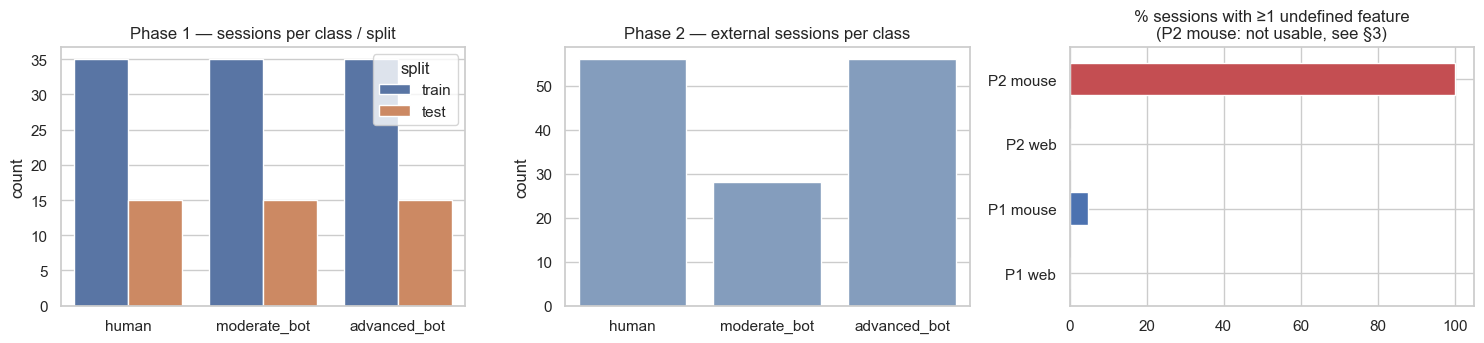

Per-feature NaN % (phase 1, features with any NaN):
mouse_pause_mean      4.7
mouse_pause_median    4.7
mouse_pause_std       4.7


In [15]:
# ---- plots: class distribution + missing-data summary
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
sns.countplot(data=master1, x='label', hue='split', order=CLASSES, ax=ax[0]); ax[0].set_title('Phase 1 — sessions per class / split'); ax[0].set_xlabel('')
sns.countplot(data=master2, x='label', order=CLASSES, color='#7a9cc6', ax=ax[1]); ax[1].set_title('Phase 2 — external sessions per class'); ax[1].set_xlabel('')
miss = pd.Series({'P1 web': feat_web.loc[master1.session_id].isna().any(axis=1).mean(), 'P1 mouse': feat_mouse.isna().any(axis=1).mean(),
                  'P2 web': feat_web.loc[list(logs2)].isna().any(axis=1).mean(), 'P2 mouse': 1.0}) * 100
miss.plot.barh(ax=ax[2], color=['#4c72b0', '#4c72b0', '#55a868', '#c44e52']); ax[2].set_title('% sessions with ≥1 undefined feature\n(P2 mouse: not usable, see §3)'); ax[2].set_xlim(0, 105)
plt.tight_layout(); plt.show()
print('Per-feature NaN % (phase 1, features with any NaN):')
nan_pct = pd.concat([feat_web.loc[master1.session_id], feat_mouse], axis=1).isna().mean().mul(100)
print(nan_pct[nan_pct > 0].round(1).sort_values(ascending=False).head(12).to_string() or 'none')

## 11. Dataset Construction

Saved datasets/fairdrop_session_features.csv  rows=290  columns=107  (id/label/split/phase + 103 candidate features)
Rows with NaN mouse block (phase 2 by design): 140


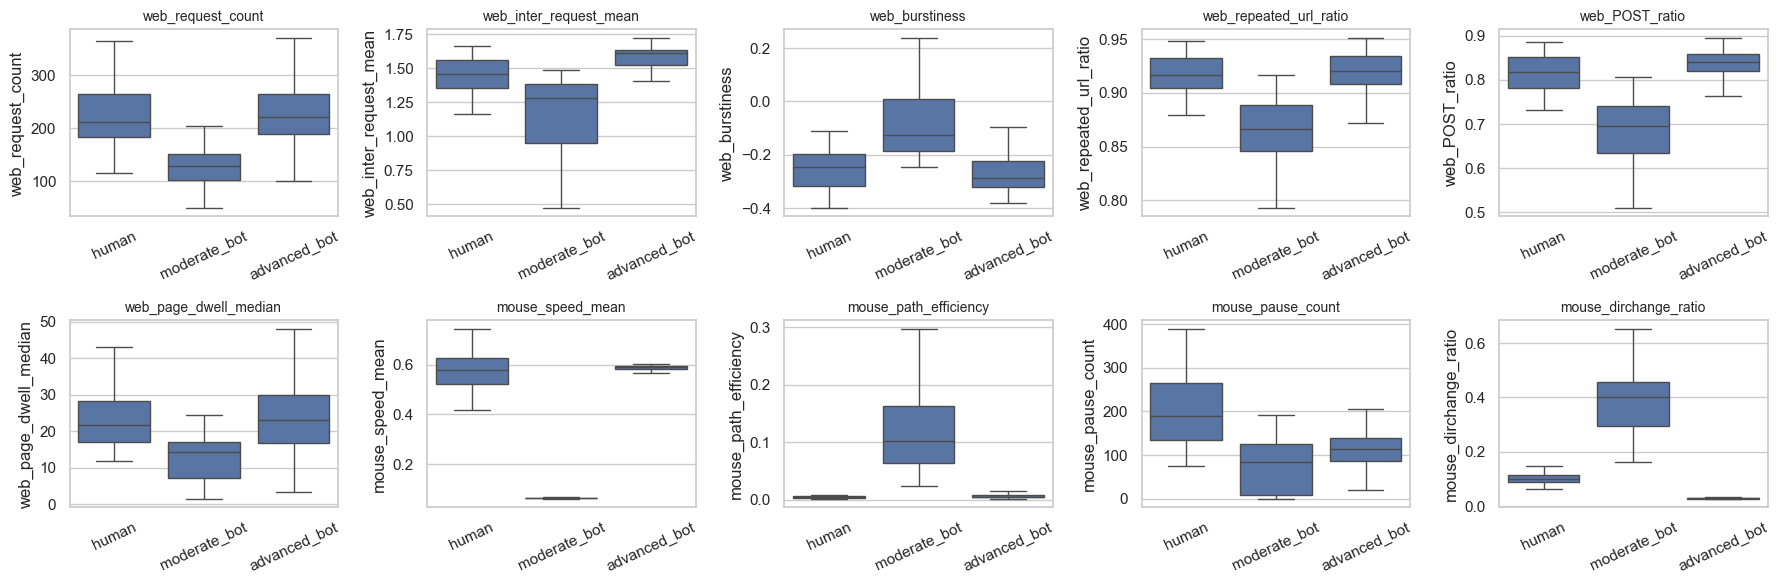

In [16]:
feat_all = pd.concat([feat_web, feat_ua], axis=1).join(feat_mouse, how='left')
ds = master.set_index('session_id').join(feat_all, how='left')
assert ds[[c for c in feat_web.columns]].notna().any(axis=1).all(), 'labeled session without web features'
FEAT_COLS_ALL = [c for c in feat_all.columns]
ds_out = ds.reset_index()
ds_out.to_csv(OUT_DIR / 'datasets' / 'fairdrop_session_features.csv', index=False)
print(f'Saved datasets/fairdrop_session_features.csv  rows={len(ds_out)}  columns={ds_out.shape[1]}  (id/label/split/phase + {len(FEAT_COLS_ALL)} candidate features)')
print('Rows with NaN mouse block (phase 2 by design):', int(ds_out.mouse_move_count.isna().sum()))

# selected feature distributions (phase 1, train) — boxplots by class
sel = ['web_request_count', 'web_inter_request_mean', 'web_burstiness', 'web_repeated_url_ratio', 'web_POST_ratio', 'web_page_dwell_median',
       'mouse_speed_mean', 'mouse_path_efficiency', 'mouse_pause_count', 'mouse_dirchange_ratio']
d1 = ds[ds.phase == 1]
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for a, c in zip(axes.ravel(), sel):
    sns.boxplot(data=d1, x='label', y=c, order=CLASSES, ax=a, showfliers=False); a.set_xlabel(''); a.set_title(c, fontsize=10)
    a.tick_params(axis='x', labelrotation=25)
plt.tight_layout(); plt.show()

## 12. Leakage Checks
Counts only. Includes a **user-agent leakage test**: if a UA-only model separates the classes well, those features would let the model memorise how this dataset's bots were built rather than learn behaviour, so they stay out.

In [17]:
S_train = set(master1.query("split=='train'").session_id); S_test = set(master1.query("split=='test'").session_id)
labeled1 = set(master1.session_id)
log_sids_p1 = set(req1.sid); mouse_sids_p1 = set(mouse1)
checks = {
    'duplicate session ids in master': int(master.session_id.duplicated().sum()),
    'train ∩ test (phase 1)': len(S_train & S_test),
    'phase1 ∩ phase2 session ids': len(labeled1 & set(master2.session_id)),
    'labeled sessions with missing label': int(master.label.isna().sum()),
    'phase1 labeled sessions without web logs': len(labeled1 - log_sids_p1),
    'phase1 labeled sessions without mouse data': len(labeled1 - mouse_sids_p1),
    'phase1 sessions with logs but no label': len(log_sids_p1 - labeled1),
    'phase1 sessions with mouse data but no label': len(mouse_sids_p1 - labeled1),
    'phase2 labeled sessions without web logs': len(set(master2.session_id) - set(req2.sid)),
    'phase2 sessions with logs but no label (after id split)': len(set(req2.sid) - set(master2.session_id)),
}
print(pd.Series(checks).to_string())
assert checks['train ∩ test (phase 1)'] == 0 and checks['duplicate session ids in master'] == 0

# date confound: collection dates differ by class -> absolute time must never be a feature
t0 = req1[req1.sid.isin(labeled1)].groupby('sid').ts.min().map(lambda s: datetime.datetime.fromtimestamp(s, datetime.timezone.utc).date())
print('\nphase1 session start dates by class:'); print(pd.DataFrame({'date': t0, 'label': master1.set_index('session_id').label}).groupby('label').date.agg(['min', 'max']).loc[CLASSES].to_string())
print('=> no absolute-time, filename, folder or id feature is used (forbidden-name check enforced in §13).')

duplicate session ids in master                              0
train ∩ test (phase 1)                                       0
phase1 ∩ phase2 session ids                                  0
labeled sessions with missing label                          0
phase1 labeled sessions without web logs                     0
phase1 labeled sessions without mouse data                   0
phase1 sessions with logs but no label                     295
phase1 sessions with mouse data but no label                 0
phase2 labeled sessions without web logs                     0
phase2 sessions with logs but no label (after id split)    240

phase1 session start dates by class:
                     min         max
label                               
human         2019-10-27  2019-10-29
moderate_bot  2019-10-30  2019-10-30
advanced_bot  2019-11-01  2019-11-01
=> no absolute-time, filename, folder or id feature is used (forbidden-name check enforced in §13).


In [18]:
# ---- user-agent leakage test (train-only CV, then single test read-out)
ua_cols = list(feat_ua.columns)
Xua = ds.loc[master1.session_id, ua_cols]; yy = master1.set_index('session_id').label.map(CLASS_ID)
trm = (master1.split == 'train').values
cv_ua = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=SEED)
mk = lambda: xgb.XGBClassifier(objective='multi:softprob', n_estimators=100, max_depth=3, learning_rate=0.1, random_state=SEED, n_jobs=2)
ua_cv = cross_val_score(mk(), Xua[trm], yy[trm], cv=cv_ua, scoring='f1_macro', n_jobs=2)
ua_test_f1 = f1_score(yy[~trm], mk().fit(Xua[trm], yy[trm]).predict(Xua[~trm]), average='macro')
print(f'UA-only model: CV macro-F1 (train) = {ua_cv.mean():.3f} ± {ua_cv.std():.3f} | test macro-F1 = {ua_test_f1:.3f}   (chance ≈ 0.33)')
print('UA strings per class (phase 1):', ds[ds.phase == 1].groupby('label').ua_missing.mean().round(3).to_dict(), '| distinct-UA per session:', ds[ds.phase == 1].ua_distinct_count.max())
print(pd.crosstab(ds[ds.phase == 1].label, ds[ds.phase == 1][['ua_is_chrome', 'ua_is_firefox', 'ua_is_edge', 'ua_is_opera']].idxmax(axis=1)).loc[CLASSES].to_string())
ua_pred = mk().fit(Xua[trm], yy[trm]).predict(Xua[~trm]); yt_ = yy[~trm].values
ua_human_recall, ua_bot_vs_human_acc = float((ua_pred[yt_ == 0] == 0).mean()), float(((ua_pred > 0) == (yt_ > 0)).mean())
print(f'UA-only, test set: human recall = {ua_human_recall:.2f} | human-vs-any-bot accuracy = {ua_bot_vs_human_acc:.2f} | moderate-vs-advanced confusions are expected (UA cannot tell them apart)')
UA_LEAKY = ua_cv.mean() > 0.5 or ua_bot_vs_human_acc > 0.9

UA-only model: CV macro-F1 (train) = 0.556 ± 0.000 | test macro-F1 = 0.556   (chance ≈ 0.33)
UA strings per class (phase 1): {'advanced_bot': 0.0, 'human': 0.0, 'moderate_bot': 0.0} | distinct-UA per session: 1
col_0         ua_is_chrome  ua_is_opera
label                                  
human                   50            0
moderate_bot             0           50
advanced_bot             0           50
UA-only, test set: human recall = 1.00 | human-vs-any-bot accuracy = 1.00 | moderate-vs-advanced confusions are expected (UA cannot tell them apart)


In [19]:
# decision (documented, data-driven): UA-derived and protocol-fingerprint features are excluded from every feature set.
print('Decision: UA-derived features RETAINED' if not UA_LEAKY else
      f'Decision: UA-derived features REMOVED — UA strings alone separate humans from bots with accuracy {ua_bot_vs_human_acc:.2f} on the test set (UA-only 3-class CV macro-F1 {ua_cv.mean():.2f}, chance 0.33). '
      'The crosstab above shows the browser family is a property of how this dataset was collected (one family per class group), not behaviour. Final features are behavioural only.')
print('Even if the UA features were harmless on this dataset, FairDrop bots will present different UA strings, so excluding them is the safer default.')

Decision: UA-derived features REMOVED — UA strings alone separate humans from bots with accuracy 1.00 on the test set (UA-only 3-class CV macro-F1 0.56, chance 0.33). The crosstab above shows the browser family is a property of how this dataset was collected (one family per class group), not behaviour. Final features are behavioural only.
Even if the UA features were harmless on this dataset, FairDrop bots will present different UA strings, so excluding them is the safer default.


## 13. Train / Validation / Test Setup

In [20]:
D1 = ds[ds.phase == 1]
train_df, test_df = D1[D1.split == 'train'], D1[D1.split == 'test']
D2 = ds[ds.phase == 2]
y_train = train_df.label.map(CLASS_ID).values; y_test = test_df.label.map(CLASS_ID).values; y_ext = D2.label.map(CLASS_ID).values
assert (train_df.index.values == tr_ids).all()          # same ordering used for the inner split in §10

FORBIDDEN = re.compile(r'^(session_id|sid|sid_orig|file.*|folder.*|annotation.*|ann_file|split|label|phase|ts|tstr|date.*|start_time.*|.*filename.*)$', re.I)
cand_web, cand_mouse = [c for c in FEAT_COLS_ALL if c.startswith('web_')], [c for c in FEAT_COLS_ALL if c.startswith('mouse_')]
assert not [c for c in cand_web + cand_mouse if FORBIDDEN.search(c)], 'forbidden feature name'

def clean_cols(cols, Xtr, thr=CORR_THR):
    nun = Xtr[cols].nunique(dropna=True)
    const = nun[nun <= 1].index.tolist()
    keep = [c for c in cols if c not in const]
    corr = Xtr[keep].corr().abs(); drop = []
    for i, a in enumerate(keep):
        if a in drop: continue
        for b in keep[i + 1:]:
            if b not in drop and corr.loc[a, b] > thr: drop.append(b)
    return [c for c in keep if c not in drop], const, drop

FEATURE_SETS, CLEAN_REPORT = {}, {}
for name, cols in [('A_web', cand_web), ('B_mouse', cand_mouse), ('C_web_mouse', cand_web + cand_mouse)]:
    kept, const, drop = clean_cols(cols, train_df)
    FEATURE_SETS[name] = kept; CLEAN_REPORT[name] = dict(candidates=len(cols), constant_removed=len(const), correlated_removed=len(drop), final=len(kept))
print(pd.DataFrame(CLEAN_REPORT).T.to_string())
print('constant (train) web features removed:', [c for c in cand_web if c not in clean_cols(cand_web, train_df)[0] and c in clean_cols(cand_web, train_df)[1]])
print(f'\nSplits: train={len(train_df)} (inner fit {len(inner_tr)} / inner val {len(inner_va)}), test={len(test_df)}, external phase2={len(D2)}. '
      'Preprocessing: constant + |r|>%.2f columns dropped using TRAIN only; NaN kept for XGBoost, median-imputed + scaled for Logistic Regression (fit on train).' % CORR_THR)

             candidates  constant_removed  correlated_removed  final
A_web                46                 9                  13     24
B_mouse              43                 1                   4     38
C_web_mouse          89                10                  18     61
constant (train) web features removed: ['web_other_method_count', 'web_method_diversity', 'web_HTTP_3xx_count', 'web_HTTP_4xx_count', 'web_HTTP_5xx_count', 'web_error_rate', 'web_inter_request_min', 'web_long_pause_count', 'web_referrer_missing_ratio']

Splits: train=105 (inner fit 84 / inner val 21), test=45, external phase2=140. Preprocessing: constant + |r|>0.98 columns dropped using TRAIN only; NaN kept for XGBoost, median-imputed + scaled for Logistic Regression (fit on train).


## 14. Baseline Models
Majority-class and Logistic Regression baselines on each feature set. Common helpers (metrics, CV splits) are defined here and reused below.

In [21]:
CV_SPLITS = list(RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=SEED).split(np.zeros(len(y_train)), y_train))

def getX(df, cols): return df[cols].astype(float)

def metrics_from_proba(y, proba):
    pred = proba.argmax(1); labels = [0, 1, 2]
    C = confusion_matrix(y, pred, labels=labels)
    p, r, f, s = precision_recall_fscore_support(y, pred, labels=labels, zero_division=0)
    d = dict(accuracy=accuracy_score(y, pred), balanced_accuracy=balanced_accuracy_score(y, pred),
             macro_precision=p.mean(), macro_recall=r.mean(), macro_f1=f.mean(), weighted_f1=f1_score(y, pred, average='weighted'))
    for i, c in enumerate(CLASSES): d.update({f'{c}_precision': p[i], f'{c}_recall': r[i], f'{c}_f1': f[i], f'{c}_support': int(s[i])})
    onehot = np.eye(3)[y]
    d['roc_auc_ovr_macro'] = roc_auc_score(y, proba, multi_class='ovr', average='macro') if len(set(y)) == 3 else np.nan
    d['pr_auc_macro'] = average_precision_score(onehot, proba, average='macro')
    d['log_loss'] = log_loss(y, np.clip(proba, 1e-7, 1), labels=labels); d['brier'] = float(((proba - onehot) ** 2).sum(1).mean())
    d['human_to_any_bot_rate'] = (C[0, 1] + C[0, 2]) / C[0].sum(); d['bot_to_human_rate'] = (C[1, 0] + C[2, 0]) / (C[1].sum() + C[2].sum())
    d['moderate_to_human_rate'] = C[1, 0] / C[1].sum(); d['advanced_to_human_rate'] = C[2, 0] / C[2].sum()
    return d, C

def bootstrap_ci(y, proba, stat=lambda y, p: f1_score(y, p, average='macro'), n=1000, seed=SEED):
    rng = np.random.default_rng(seed); pred = proba.argmax(1); vals = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y)); vals.append(stat(y[i], pred[i]))
    return np.percentile(vals, [2.5, 97.5])

RES, CVRES = {}, {}                  # RES[(model, set)] = (metrics, confusion, proba)
def lr_pipe(): return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(C=1.0, max_iter=5000, random_state=SEED))

for sname, cols in FEATURE_SETS.items():
    Xtr, Xte = getX(train_df, cols), getX(test_df, cols)
    for mname, mk_model in [('Majority', lambda: make_pipeline(SimpleImputer(strategy='median'), DummyClassifier(strategy='most_frequent'))), ('LogReg', lr_pipe)]:
        cv = cross_val_score(mk_model(), Xtr, y_train, cv=CV_SPLITS, scoring='f1_macro')
        m = mk_model().fit(Xtr, y_train); proba = m.predict_proba(Xte)
        if proba.shape[1] < 3: proba = np.pad(proba, ((0, 0), (0, 3 - proba.shape[1])))
        met, C = metrics_from_proba(y_test, proba); RES[(mname, sname)] = (met, C, proba); CVRES[(mname, sname)] = (cv.mean(), cv.std())
base_tab = pd.DataFrame([{'model': k[0], 'feature_set': k[1], 'cv_macro_f1': f'{CVRES[k][0]:.3f}±{CVRES[k][1]:.3f}', 'test_acc': RES[k][0]['accuracy'], 'test_macro_f1': RES[k][0]['macro_f1']}
                         for k in RES]).round(3)
print(base_tab.to_string(index=False))

   model feature_set cv_macro_f1  test_acc  test_macro_f1
Majority       A_web 0.167±0.000     0.333          0.167
  LogReg       A_web 0.846±0.044     0.867          0.866
Majority     B_mouse 0.167±0.000     0.333          0.167
  LogReg     B_mouse 0.995±0.014     1.000          1.000
Majority C_web_mouse 0.167±0.000     0.333          0.167
  LogReg C_web_mouse 0.995±0.014     1.000          1.000


## 15. XGBoost Training
Controlled-complexity multiclass XGBoost (`multi:softprob`, shallow trees, L1/L2 regularisation, row/column subsampling, fixed seed). First an **untuned reference** with early stopping on the inner validation split (no test data involved).

In [22]:
def make_xgb(params=None, **kw):
    base = dict(objective='multi:softprob', tree_method='hist', random_state=SEED, n_jobs=1, eval_metric='mlogloss', verbosity=0)
    base.update(params or {}); base.update(kw)
    return xgb.XGBClassifier(**base)

REF_PARAMS = dict(max_depth=3, learning_rate=0.1, n_estimators=400, subsample=0.8, colsample_bytree=0.7, min_child_weight=2, reg_alpha=0.1, reg_lambda=5)
colsC = FEATURE_SETS['C_web_mouse']; XtrC = getX(train_df, colsC)
ref = make_xgb(REF_PARAMS, early_stopping_rounds=30)
ref.fit(XtrC.iloc[inner_tr], y_train[inner_tr], eval_set=[(XtrC.iloc[inner_va], y_train[inner_va])], verbose=False)
pv = ref.predict_proba(XtrC.iloc[inner_va])
print(f'Reference XGB (Web+Mouse, {len(colsC)} features): early-stopped at {ref.best_iteration+1} trees | inner-val macro-F1 = {f1_score(y_train[inner_va], pv.argmax(1), average="macro"):.3f} | '
      f'inner-val mlogloss = {log_loss(y_train[inner_va], pv, labels=[0,1,2]):.3f}  (n_val={len(inner_va)}; noisy by construction)')

Reference XGB (Web+Mouse, 61 features): early-stopped at 153 trees | inner-val macro-F1 = 1.000 | inner-val mlogloss = 0.042  (n_val=21; noisy by construction)


## 16. Compact Hyperparameter Tuning
Random search (24 configs) over `max_depth, learning_rate, n_estimators, subsample, colsample_bytree, min_child_weight, reg_alpha, reg_lambda`, scored by **session-level repeated stratified 5-fold CV macro-F1 on the training set only**. The test set is never used here. The final model per feature set is refit on the full training set; `n_estimators` may be shortened (never below 50% of the CV choice) by early stopping on the inner validation split.

An extra **ablation** feature set (*web without the POST telemetry beacon*) is built to show how much of the web signal comes from the dataset's mouse-upload instrumentation.

In [23]:
# ablation features: web features recomputed WITHOUT POST requests (the dataset's mouse-telemetry beacon)
grp_nb = {sid: grp[sid][grp[sid].method != 'POST'] for sid in master1.session_id}
assert min(len(g) for g in grp_nb.values()) > 0
feat_web_nb = pd.DataFrame.from_dict({sid: web_features(g) for sid, g in grp_nb.items()}, orient='index')
nb_train, nb_test = feat_web_nb.loc[train_df.index], feat_web_nb.loc[test_df.index]
nb_cols, nb_const, nb_corr = clean_cols(list(feat_web_nb.columns), nb_train)
SET_DATA = {s: (getX(train_df, c), getX(test_df, c)) for s, c in FEATURE_SETS.items()}
SET_DATA['D_web_nobeacon'] = (nb_train[nb_cols].astype(float), nb_test[nb_cols].astype(float)); FEATURE_SETS['D_web_nobeacon'] = nb_cols
print({s: len(c) for s, c in FEATURE_SETS.items()}, '| beacon-free set: POST-derived columns became constant and were removed:', len(nb_const))

def cv_one(params, X, y):
    sc = []
    for tr, va in CV_SPLITS:
        m = make_xgb(params).fit(X.iloc[tr], y[tr]); sc.append(f1_score(y[va], m.predict(X.iloc[va]), average='macro'))
    return float(np.mean(sc)), float(np.std(sc))

def tune(X, y):
    cfgs = list(ParameterSampler(PARAM_GRID, n_iter=N_ITER, random_state=SEED))
    out = Parallel(n_jobs=2)(delayed(cv_one)(c, X, y) for c in cfgs)
    tab = pd.DataFrame(cfgs).assign(cv_f1=[o[0] for o in out], cv_std=[o[1] for o in out]).sort_values('cv_f1', ascending=False).reset_index(drop=True)
    return tab

def fit_final(params, X, y):
    cap = max(300, params['n_estimators'])
    es = make_xgb({**params, 'n_estimators': cap}, early_stopping_rounds=30)
    es.fit(X.iloc[inner_tr], y[inner_tr], eval_set=[(X.iloc[inner_va], y[inner_va])], verbose=False)
    n_final = int(max(es.best_iteration + 1, np.ceil(0.5 * params['n_estimators'])))
    return make_xgb({**params, 'n_estimators': n_final}).fit(X, y), n_final

TUNE, BEST, MODELS = {}, {}, {}
t0 = time.time()
for s, (Xtr, Xte) in SET_DATA.items():
    TUNE[s] = tune(Xtr, y_train)
    keys = ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree', 'min_child_weight', 'reg_alpha', 'reg_lambda']
    BEST[s] = {k: (TUNE[s].loc[0, k].item() if hasattr(TUNE[s].loc[0, k], 'item') else TUNE[s].loc[0, k]) for k in keys}
    MODELS[s], n_final = fit_final(BEST[s], Xtr, y_train)
    BEST[s]['n_estimators_final'] = n_final
    CVRES[('XGBoost', s)] = (TUNE[s].loc[0, 'cv_f1'], TUNE[s].loc[0, 'cv_std'])
    proba = MODELS[s].predict_proba(Xte); met, C = metrics_from_proba(y_test, proba); RES[('XGBoost', s)] = (met, C, proba)
    print(f'{s:16s} features={Xtr.shape[1]:3d}  best CV macro-F1={TUNE[s].loc[0,"cv_f1"]:.3f}±{TUNE[s].loc[0,"cv_std"]:.3f}  '
          f'(median of 24 configs: {TUNE[s].cv_f1.median():.3f})  final trees={n_final}')
print(f'tuning wall time: {time.time()-t0:.0f}s')
print('\nBest params per feature set:'); print(pd.DataFrame(BEST).T.to_string())

{'A_web': 24, 'B_mouse': 38, 'C_web_mouse': 61, 'D_web_nobeacon': 25} | beacon-free set: POST-derived columns became constant and were removed: 11
A_web            features= 24  best CV macro-F1=0.904±0.053  (median of 24 configs: 0.877)  final trees=278
B_mouse          features= 38  best CV macro-F1=1.000±0.000  (median of 24 configs: 0.995)  final trees=299
C_web_mouse      features= 61  best CV macro-F1=1.000±0.000  (median of 24 configs: 0.990)  final trees=299
D_web_nobeacon   features= 25  best CV macro-F1=0.951±0.044  (median of 24 configs: 0.932)  final trees=50
tuning wall time: 41s

Best params per feature set:
                max_depth  learning_rate  n_estimators  subsample  colsample_bytree  min_child_weight  reg_alpha  reg_lambda  n_estimators_final
A_web                 5.0           0.10          50.0        0.6               0.7               4.0        0.1         1.0               278.0
B_mouse               2.0           0.05         200.0        0.6               

In [24]:
# Model selection for the exported model uses ONLY training-set CV (never test). Ties -> prefer the earlier-listed set.
CANDIDATES = ['C_web_mouse', 'A_web', 'B_mouse']
SEL = max(CANDIDATES, key=lambda s: (round(CVRES[('XGBoost', s)][0], 4), -CANDIDATES.index(s)))
print('CV macro-F1 (train):', {s: round(CVRES[('XGBoost', s)][0], 3) for s in CANDIDATES}, '=> exported feature set:', SEL)

CV macro-F1 (train): {'C_web_mouse': np.float64(1.0), 'A_web': np.float64(0.904), 'B_mouse': np.float64(1.0)} => exported feature set: C_web_mouse


## 17. Evaluation (official test set, 45 sessions)
Test metrics for the selected model, plus 95% session-bootstrap confidence intervals (n=45 → wide intervals; treat point estimates with care).

Selected model: XGBoost / C_web_mouse / 61 features
accuracy             1.0000
balanced_accuracy    1.0000
macro_precision      1.0000
macro_recall         1.0000
macro_f1             1.0000
weighted_f1          1.0000
roc_auc_ovr_macro    1.0000
pr_auc_macro         1.0000
log_loss             0.0695
brier                0.0152
macro-F1 bootstrap 95% CI: [1.000, 1.000] | accuracy bootstrap 95% CI: [1.000, 1.000] | accuracy exact (Clopper-Pearson) 95% CI: [0.921, 1.000]
(a bootstrap CI collapses to a point when every test session is correct; the exact binomial interval is the honest uncertainty for n=45)
(ROC-AUC/PR-AUC: one-vs-rest macro on 15 sessions per class — indicative only. Probabilities are NOT calibrated; log-loss/Brier shown for transparency.)

              precision  recall   f1  support
human               1.0     1.0  1.0     15.0
moderate_bot        1.0     1.0  1.0     15.0
advanced_bot        1.0     1.0  1.0     15.0
macro avg           1.0     1.0  1.0     45.0
wei

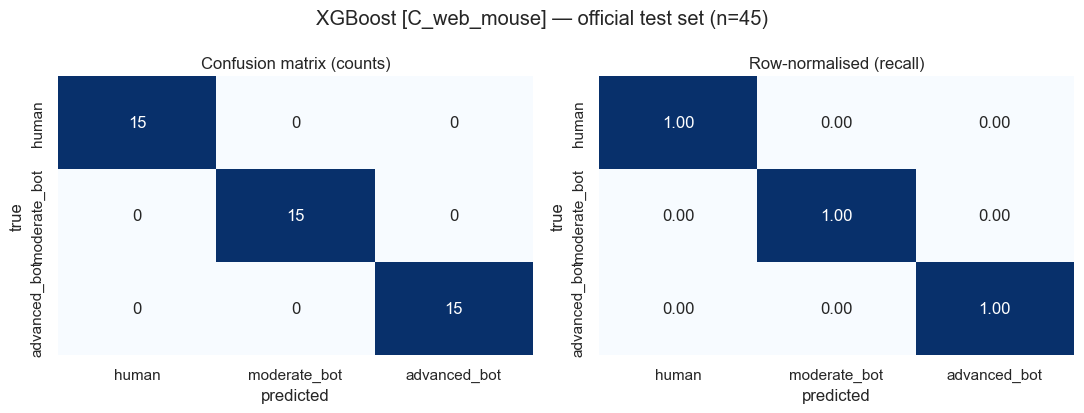

In [25]:
met, C, proba = RES[('XGBoost', SEL)]
ci_f1 = bootstrap_ci(y_test, proba); ci_acc = bootstrap_ci(y_test, proba, stat=accuracy_score)
print(f'Selected model: XGBoost / {SEL} / {len(FEATURE_SETS[SEL])} features')
overall = pd.Series({k: met[k] for k in ['accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'roc_auc_ovr_macro', 'pr_auc_macro', 'log_loss', 'brier']}).round(4)
print(overall.to_string())
from scipy.stats import binomtest
cp = binomtest(int(round(met['accuracy'] * len(y_test))), len(y_test)).proportion_ci(method='exact')
print(f'macro-F1 bootstrap 95% CI: [{ci_f1[0]:.3f}, {ci_f1[1]:.3f}] | accuracy bootstrap 95% CI: [{ci_acc[0]:.3f}, {ci_acc[1]:.3f}] | accuracy exact (Clopper-Pearson) 95% CI: [{cp.low:.3f}, {cp.high:.3f}]')
print('(a bootstrap CI collapses to a point when every test session is correct; the exact binomial interval is the honest uncertainty for n=%d)' % len(y_test))
print('(ROC-AUC/PR-AUC: one-vs-rest macro on 15 sessions per class — indicative only. Probabilities are NOT calibrated; log-loss/Brier shown for transparency.)')

rep = pd.DataFrame({c: [met[f'{c}_precision'], met[f'{c}_recall'], met[f'{c}_f1'], met[f'{c}_support']] for c in CLASSES}, index=['precision', 'recall', 'f1', 'support']).T
rep.loc['macro avg'] = [met['macro_precision'], met['macro_recall'], met['macro_f1'], len(y_test)]
rep.loc['weighted avg'] = [np.average([met[f'{c}_precision'] for c in CLASSES], weights=[met[f'{c}_support'] for c in CLASSES]),
                           np.average([met[f'{c}_recall'] for c in CLASSES], weights=[met[f'{c}_support'] for c in CLASSES]), met['weighted_f1'], len(y_test)]
rep.loc['accuracy'] = [np.nan, np.nan, met['accuracy'], len(y_test)]
rep.round(4).to_csv(OUT_DIR / 'results' / 'classification_report.csv'); print(); print(rep.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(C, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0], cbar=False); ax[0].set_title('Confusion matrix (counts)')
sns.heatmap(C / C.sum(1, keepdims=True), annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1], cbar=False, vmin=0, vmax=1); ax[1].set_title('Row-normalised (recall)')
for a in ax: a.set_xlabel('predicted'); a.set_ylabel('true')
plt.suptitle(f'XGBoost [{SEL}] — official test set (n={len(y_test)})'); plt.tight_layout(); plt.savefig(OUT_DIR / 'results' / 'confusion_matrix.png', dpi=140); plt.show()

## 18. Web vs Mouse vs Combined Comparison
All rows use the same protocol: tuning by session-level CV on train, single read-out on the official test set. `Web (no beacon)` is the ablation described in §16.

XGBoost — required comparison (test set):
                        Feature Set  Accuracy  Macro F1  Human Recall  Moderate Bot F1  Advanced Bot F1 Macro-F1 95% CI  CV Macro-F1 (train)
                         Mouse only    1.0000    1.0000        1.0000           1.0000           1.0000    [1.00, 1.00]               1.0000
                        Web + Mouse    1.0000    1.0000        1.0000           1.0000           1.0000    [1.00, 1.00]               1.0000
                           Web only    0.9111    0.9110        0.9333           0.9333           0.8966    [0.81, 0.98]               0.9039
Web only, no POST beacon (ablation)    0.9333    0.9332        1.0000           0.9655           0.8966    [0.84, 1.00]               0.9513

All models (test set):
   model                         feature_set  accuracy  macro_f1  human_recall  advanced_bot_f1  cv_macro_f1_train
  LogReg                          Mouse only    1.0000    1.0000        1.0000           1.0000             0.9952

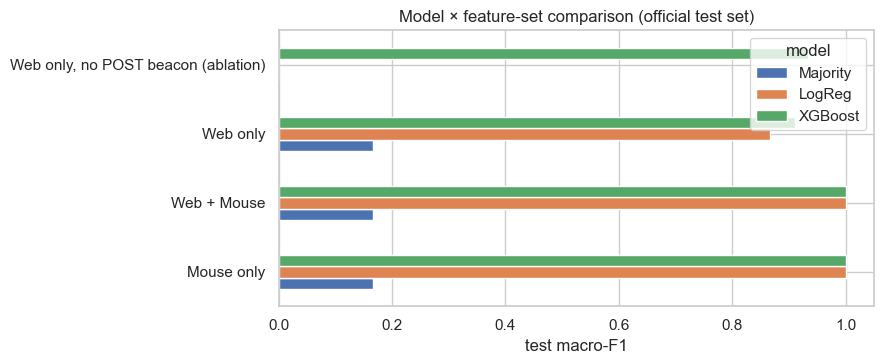

In [26]:
NAMES = {'A_web': 'Web only', 'B_mouse': 'Mouse only', 'C_web_mouse': 'Web + Mouse', 'D_web_nobeacon': 'Web only, no POST beacon (ablation)'}
rows = []
for (mname, s), (m, C_, p_) in RES.items():
    cvm, cvs = CVRES[(mname, s)]
    rows.append({'model': mname, 'feature_set': NAMES.get(s, s), 'n_features': len(FEATURE_SETS[s]), 'cv_macro_f1_train': round(cvm, 4), 'cv_std': round(cvs, 4),
                 'accuracy': m['accuracy'], 'balanced_accuracy': m['balanced_accuracy'], 'macro_f1': m['macro_f1'], 'weighted_f1': m['weighted_f1'],
                 'human_recall': m['human_recall'], 'moderate_bot_f1': m['moderate_bot_f1'], 'advanced_bot_f1': m['advanced_bot_f1'],
                 'human_to_any_bot_rate': m['human_to_any_bot_rate'], 'advanced_to_human_rate': m['advanced_to_human_rate'], 'moderate_to_human_rate': m['moderate_to_human_rate']})
comp = pd.DataFrame(rows)
comp['ci95_macro_f1'] = [f'[{lo:.2f}, {hi:.2f}]' for lo, hi in (bootstrap_ci(y_test, RES[(r.model, [k for k, v in NAMES.items() if v == r.feature_set][0])][2]) for r in comp.itertuples())]
comp = comp.sort_values(['model', 'feature_set']).round(4)
comp.to_csv(OUT_DIR / 'results' / 'model_comparison.csv', index=False)

req_tab = comp[comp.model == 'XGBoost'][['feature_set', 'accuracy', 'macro_f1', 'human_recall', 'moderate_bot_f1', 'advanced_bot_f1', 'ci95_macro_f1', 'cv_macro_f1_train']]
req_tab = req_tab.rename(columns={'feature_set': 'Feature Set', 'accuracy': 'Accuracy', 'macro_f1': 'Macro F1', 'human_recall': 'Human Recall', 'moderate_bot_f1': 'Moderate Bot F1', 'advanced_bot_f1': 'Advanced Bot F1', 'ci95_macro_f1': 'Macro-F1 95% CI', 'cv_macro_f1_train': 'CV Macro-F1 (train)'})
print('XGBoost — required comparison (test set):'); print(req_tab.to_string(index=False))
print('\nAll models (test set):'); print(comp[['model', 'feature_set', 'accuracy', 'macro_f1', 'human_recall', 'advanced_bot_f1', 'cv_macro_f1_train']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.8))
pv_ = comp.pivot(index='feature_set', columns='model', values='macro_f1')[['Majority', 'LogReg', 'XGBoost']]
pv_.plot.barh(ax=ax); ax.set_xlabel('test macro-F1'); ax.set_ylabel(''); ax.set_xlim(0, 1.05); ax.set_title('Model × feature-set comparison (official test set)')
plt.tight_layout(); plt.show()

### 18b. External check on phase 2 (web modality only)
The web-only XGBoost trained on **phase‑1 train** is applied, with no refitting, to the 140 phase‑2 sessions (different web server content, different participants, 2020 collection). Mouse models cannot be evaluated (see §3).

In [27]:
colsA = FEATURE_SETS['A_web']; XextA = getX(D2, colsA)
pe = MODELS['A_web'].predict_proba(XextA); met_e, C_e = metrics_from_proba(y_ext, pe)
print({k: round(met_e[k], 3) for k in ['accuracy', 'balanced_accuracy', 'macro_f1', 'human_recall', 'moderate_bot_f1', 'advanced_bot_f1', 'human_to_any_bot_rate', 'advanced_to_human_rate', 'moderate_to_human_rate']})
print('phase-1 test (same model), for reference:', {k: round(RES[('XGBoost', 'A_web')][0][k], 3) for k in ['accuracy', 'macro_f1', 'human_recall']})
print(pd.DataFrame(C_e, index=[f'true {c}' for c in CLASSES], columns=[f'pred {c}' for c in CLASSES]).to_string())
topA = pd.Series(MODELS['A_web'].get_booster().get_score(importance_type='gain')).sort_values(ascending=False).index[:6]
print('\nMedians of the model\'s top web features by class (rows: phase/feature; cols: class):')
med = pd.concat({'phase1-train': train_df.groupby('label')[topA].median().loc[CLASSES], 'phase2': D2.groupby('label')[topA].median().loc[CLASSES]}).T
print(med.round(2).to_string())
# sanity 1: is the web signal learnable INSIDE phase 2? (grouped by PHP id so a user's two visits never straddle folds; fixed params, no tuning)
from sklearn.model_selection import StratifiedGroupKFold
g2 = master2.set_index('session_id').loc[D2.index, 'base_sid'].values
P2cv = np.zeros((len(D2), 3))
for tr, va in StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(XextA, y_ext, g2):
    P2cv[va] = make_xgb({**REF_PARAMS, 'n_estimators': 150}).fit(XextA.iloc[tr], y_ext[tr]).predict_proba(XextA.iloc[va])
within2, _ = metrics_from_proba(y_ext, P2cv)
# sanity 2: reverse transfer (fit on all of phase 2, test on phase-1 test)
rev_p = make_xgb({**REF_PARAMS, 'n_estimators': 150}).fit(XextA, y_ext).predict_proba(getX(test_df, colsA))
rev, _ = metrics_from_proba(y_test, rev_p)
print(f"\nWithin-phase-2 grouped 5-fold CV (web only): accuracy {within2['accuracy']:.3f}, macro-F1 {within2['macro_f1']:.3f}, advanced F1 {within2['advanced_bot_f1']:.3f}")
print(f"Reverse transfer phase2 -> phase1-test (web only): accuracy {rev['accuracy']:.3f}, macro-F1 {rev['macro_f1']:.3f}")
EXT = dict(metrics=met_e, confusion=C_e)

{'accuracy': 0.321, 'balanced_accuracy': 0.292, 'macro_f1': np.float64(0.238), 'human_recall': np.float64(0.732), 'moderate_bot_f1': np.float64(0.25), 'advanced_bot_f1': np.float64(0.0), 'human_to_any_bot_rate': np.float64(0.268), 'advanced_to_human_rate': np.float64(1.0), 'moderate_to_human_rate': np.float64(0.857)}
phase-1 test (same model), for reference: {'accuracy': 0.911, 'macro_f1': np.float64(0.911), 'human_recall': np.float64(0.933)}
                   pred human  pred moderate_bot  pred advanced_bot
true human                 41                  0                 15
true moderate_bot          24                  4                  0
true advanced_bot          56                  0                  0

Medians of the model's top web features by class (rows: phase/feature; cols: class):
                      phase1-train                            phase2                          
label                        human moderate_bot advanced_bot   human moderate_bot advanced_bot
web_p

## 19. Feature Importance

                            gain  share_%
mouse_speed_std            2.191   31.013
mouse_trajectory_distance  2.185   30.929
mouse_speed_median         2.122   30.042
web_page_dwell_std         0.500    7.082
mouse_speed_mean           0.009    0.121
mouse_speed_p95            0.007    0.106
mouse_x_var                0.006    0.088
mouse_const_step_ratio     0.005    0.074
mouse_dt_std               0.005    0.070
mouse_dirchange_count      0.004    0.063
mouse_zero_step_ratio      0.004    0.058
mouse_dirchange_ratio      0.004    0.054
mouse_pause_mean           0.004    0.050
mouse_turn_abs_mean        0.003    0.048
mouse_acc_std              0.003    0.045


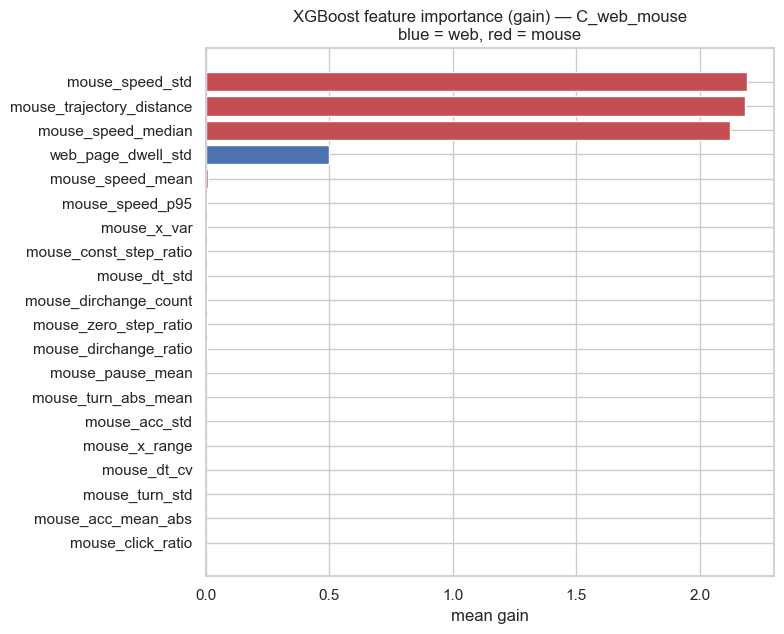

importance share by modality (%): {'mouse': 92.9, 'web': 7.1}


In [28]:
Xtr_sel, Xte_sel = SET_DATA[SEL]; model = MODELS[SEL]
imp = pd.Series(model.get_booster().get_score(importance_type='gain')).reindex(FEATURE_SETS[SEL]).fillna(0).sort_values(ascending=False)
imp_df = pd.DataFrame({'gain': imp, 'share_%': 100 * imp / imp.sum()})
print(imp_df.head(15).round(3).to_string())
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 6.5))
colors = ['#c44e52' if c.startswith('mouse_') else '#4c72b0' for c in top.index]
ax.barh(top.index, top.values, color=colors); ax.set_xlabel('mean gain'); ax.set_title(f'XGBoost feature importance (gain) — {SEL}\nblue = web, red = mouse')
plt.tight_layout(); plt.savefig(OUT_DIR / 'results' / 'feature_importance.png', dpi=140); plt.show()
grp_share = imp_df.groupby(imp_df.index.str.split('_').str[0])['share_%'].sum().round(1)
print('importance share by modality (%):', grp_share.to_dict())

## 20. SHAP / Explainability
Tree SHAP on the 45 test sessions (explanation only; no tuning). For each of the top features we report which class it influences most and in which direction — derived from the SHAP values, not asserted.

                           human  moderate_bot  advanced_bot  total
mouse_speed_std            1.805         0.000         0.000  1.805
mouse_trajectory_distance  0.000         1.732         0.000  1.732
mouse_speed_median         0.000         0.001         1.641  1.642
web_page_dwell_std         0.000         0.020         0.000  0.020
mouse_const_step_ratio     0.005         0.004         0.000  0.009
mouse_dirchange_ratio      0.000         0.008         0.000  0.008
mouse_dirchange_count      0.000         0.000         0.005  0.005
mouse_dt_std               0.000         0.000         0.005  0.005
mouse_speed_mean           0.000         0.005         0.000  0.005
mouse_zero_step_ratio      0.004         0.000         0.000  0.004

                  feature most-affected class direction (rank corr with SHAP)   rho
          mouse_speed_std               human             higher → more human  0.84
mouse_trajectory_distance        moderate_bot       lower → more moderate_bot -0.83

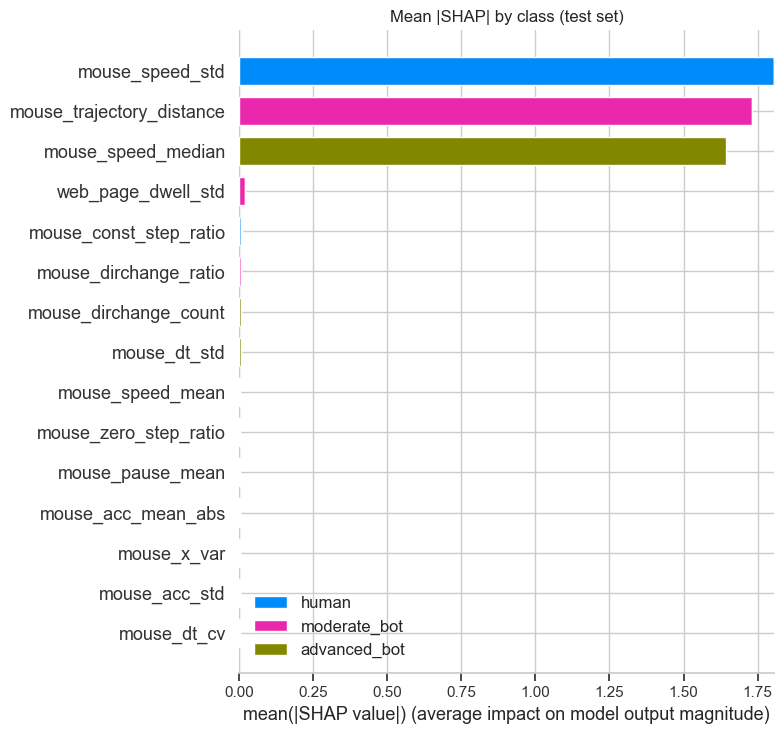

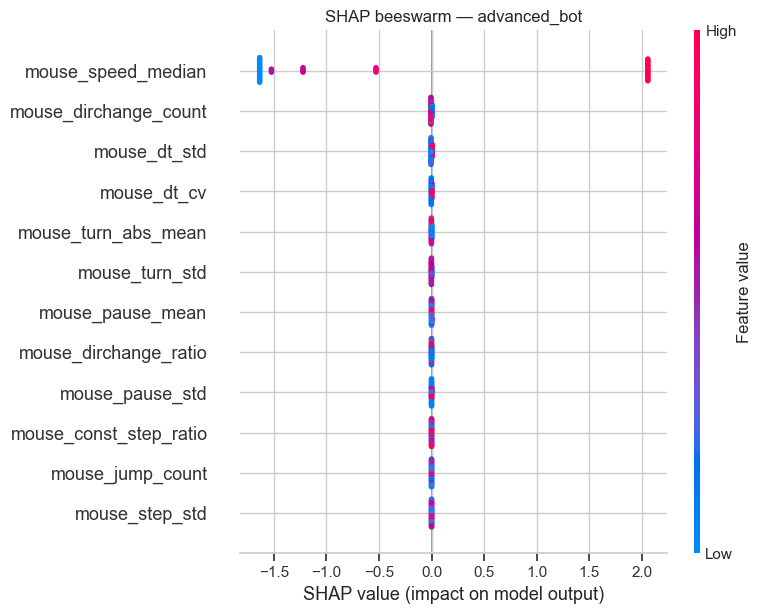

In [30]:
import shap
try:
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(Xte_sel)
    sv = np.stack(sv, axis=-1) if isinstance(sv, list) else np.asarray(sv)          # (n, features, classes)
    assert sv.shape == (len(Xte_sel), Xte_sel.shape[1], 3), sv.shape
    mabs = np.abs(sv).mean(0)                                                       # (features, classes)
    tab = pd.DataFrame(mabs, index=Xte_sel.columns, columns=CLASSES); tab['total'] = tab.sum(1); tab = tab.sort_values('total', ascending=False)
    rows = []
    for f in tab.index[:10]:
        k = int(np.argmax(mabs[list(Xte_sel.columns).index(f)])); xv = Xte_sel[f].values; ok = ~np.isnan(xv)
        r = np.corrcoef(pd.Series(xv[ok]).rank(), sv[ok, list(Xte_sel.columns).index(f), k])[0, 1] if ok.sum() > 3 else np.nan
        rows.append((f, CLASSES[k], 'higher → more ' + CLASSES[k] if r > 0 else 'lower → more ' + CLASSES[k], round(r, 2)))
    print(tab.head(10).round(3).to_string()); print(); print(pd.DataFrame(rows, columns=['feature', 'most-affected class', 'direction (rank corr with SHAP)', 'rho']).to_string(index=False))
    plt.figure(); shap.summary_plot(sv, Xte_sel, class_names=CLASSES, plot_type='bar', max_display=15, show=False)
    plt.title('Mean |SHAP| by class (test set)'); plt.tight_layout(); plt.savefig(OUT_DIR / 'results' / 'shap_summary.png', dpi=140, bbox_inches='tight'); plt.show()
    plt.figure(); shap.summary_plot(sv[:, :, 2], Xte_sel, max_display=12, show=False); plt.title('SHAP beeswarm — advanced_bot'); plt.tight_layout(); plt.show()
    SHAP_OK = True; SHAP_TOP = tab.head(10)
except Exception as e:
    SHAP_OK = False; print('SHAP failed:', repr(e))

## 21. Error Analysis
Directional error rates for the selected model on the test set, with emphasis on **human vs advanced bot** (the hardest and most FairDrop-relevant pair).

In [31]:
m_, C_, p_ = RES[('XGBoost', SEL)]
ea = pd.Series({
    'HUMAN → any bot (false-positive on humans)': f'{C_[0,1]+C_[0,2]}/{C_[0].sum()}  ({m_["human_to_any_bot_rate"]:.1%})',
    '   human → moderate / → advanced': f'{C_[0,1]} / {C_[0,2]}',
    'BOT → human (missed bots)': f'{C_[1,0]+C_[2,0]}/{C_[1].sum()+C_[2].sum()}  ({m_["bot_to_human_rate"]:.1%})',
    '   MODERATE → human': f'{C_[1,0]}/{C_[1].sum()}  ({m_["moderate_to_human_rate"]:.1%})',
    '   ADVANCED → human': f'{C_[2,0]}/{C_[2].sum()}  ({m_["advanced_to_human_rate"]:.1%})',
    'moderate ↔ advanced confusions': f'{C_[1,2]} + {C_[2,1]}'})
print(ea.to_string())

# human vs advanced as a binary problem (continuous score = P(adv)/(P(adv)+P(human)))
msk = np.isin(y_test, [0, 2]); sc = p_[msk, 2] / (p_[msk, 2] + p_[msk, 0] + 1e-12)
auc_ha = roc_auc_score((y_test[msk] == 2).astype(int), sc)
rng = np.random.default_rng(SEED); yb = (y_test[msk] == 2).astype(int)
bs = [roc_auc_score(yb[i], sc[i]) for i in (rng.integers(0, len(yb), len(yb)) for _ in range(1000)) if 0 < yb[i].sum() < len(yb)]
print(f'\nHuman vs ADVANCED only: ROC-AUC = {auc_ha:.3f} (95% bootstrap CI [{np.percentile(bs,2.5):.2f}, {np.percentile(bs,97.5):.2f}], n={msk.sum()}) | pairwise accuracy = {((sc>0.5)==yb).mean():.3f}')
msk2 = np.isin(y_test, [0, 1]); sc2 = p_[msk2, 1] / (p_[msk2, 1] + p_[msk2, 0] + 1e-12)
print(f'Human vs MODERATE only: ROC-AUC = {roc_auc_score((y_test[msk2]==1).astype(int), sc2):.3f}')
human_vs_adv_auc = float(auc_ha)

# how "easy" is this dataset? univariate separability of each feature (train, one-vs-rest AUC) and the top SHAP features' class ranges
from sklearn.metrics import roc_auc_score as _auc
uni = {}
for c in FEATURE_SETS[SEL]:
    v = train_df[c].astype(float); ok = v.notna().values
    uni[c] = [max(_auc((y_train[ok] == k).astype(int), v[ok]), 1 - _auc((y_train[ok] == k).astype(int), v[ok])) for k in range(3)]
uni = pd.DataFrame(uni, index=CLASSES).T
print('\nFeatures that ALONE separate a class (one-vs-rest AUC >= 0.95, train):', {c: int((uni[c] >= 0.95).sum()) for c in CLASSES}, 'of', len(uni))
tops = uni.max(1).sort_values(ascending=False).index[:3]
rng_tab = pd.concat({f: pd.concat([train_df, test_df]).groupby('label')[f].agg(['min', 'median', 'max']).loc[CLASSES] for f in tops}).round(3)
print('Per-class range of the 3 most separable features (train+test):'); print(rng_tab.to_string())
print('=> if class ranges barely overlap on single features, the dataset is separable by the bots\' generator signatures — treat the perfect scores as dataset-specific, not evidence for FairDrop.')

wrong = np.where(p_.argmax(1) != y_test)[0]
mis = pd.DataFrame({'session_id': test_df.index[wrong].str[:8] + '…', 'true': [CLASSES[i] for i in y_test[wrong]], 'pred': [CLASSES[i] for i in p_[wrong].argmax(1)],
                    **{f'p_{c}': p_[wrong, i].round(2) for i, c in enumerate(CLASSES)}})
print(f'\nMisclassified test sessions: {len(wrong)}/{len(y_test)}'); print(mis.to_string(index=False) if len(wrong) else '(none)')
# robustness: the same directional rates across feature sets
print('\nHuman→bot / Advanced→human rate by feature set:', {NAMES[s]: (f"{RES[('XGBoost', s)][0]['human_to_any_bot_rate']:.2f}", f"{RES[('XGBoost', s)][0]['advanced_to_human_rate']:.2f}") for s in SET_DATA})

HUMAN → any bot (false-positive on humans)    0/15  (0.0%)
   human → moderate / → advanced                     0 / 0
BOT → human (missed bots)                     0/30  (0.0%)
   MODERATE → human                           0/15  (0.0%)
   ADVANCED → human                           0/15  (0.0%)
moderate ↔ advanced confusions                       0 + 0

Human vs ADVANCED only: ROC-AUC = 1.000 (95% bootstrap CI [1.00, 1.00], n=30) | pairwise accuracy = 1.000
Human vs MODERATE only: ROC-AUC = 1.000

Features that ALONE separate a class (one-vs-rest AUC >= 0.95, train): {'human': 12, 'moderate_bot': 15, 'advanced_bot': 8} of 61
Per-class range of the 3 most separable features (train+test):
                                      min  median    max
                      label                             
mouse_speed_p95       human         1.125   1.929  2.751
                      moderate_bot  0.083   0.088  0.089
                      advanced_bot  1.060   1.127  1.127
mouse_speed_median  

## 22. Inference Function
Contract: **session telemetry in → class probabilities + `risk_score` out.**
`risk_score = 1 − P(human)` — the probability mass the model puts on *any* bot class. It is a **model output score, not a calibrated real-world probability** (calibration was not evaluated). The function has no side effects: it never allocates seats, mutates inventory or decides queue admission; thresholds and actions belong to the deterministic policy layer.

In [32]:
ART = dict(model=MODELS[SEL], columns=list(FEATURE_SETS[SEL]), classes=CLASSES, version=MODEL_VERSION)

def build_session_features(requests_df, mouse=None):
    # raw session telemetry -> feature dict. requests_df: rows of ONE session (columns as in `req`); mouse: dict(t,x,y,left,right,middle) or None
    f = web_features(requests_df)
    if mouse is not None: f.update(mouse_features(mouse))
    return f

def predict_session(features, session_id=None, artifacts=None):
    a = artifacts or ART
    row = pd.DataFrame([features]).reindex(columns=a['columns']).astype(float)       # absent features -> NaN (handled natively)
    p = a['model'].predict_proba(row)[0]
    probs = {c: round(float(p[i]), 4) for i, c in enumerate(a['classes'])}
    return {'session_id': session_id, 'classification': a['classes'][int(np.argmax(p))], 'probabilities': probs,
            'risk_score': round(float(1.0 - p[0]), 4), 'model_version': a['version']}

# demo: one test session per class, from RAW telemetry, must reproduce the batch probabilities exactly
for cls in CLASSES:
    sid = test_df[test_df.label == cls].index[0]
    feats = build_session_features(grp[sid], mouse1.get(sid))
    out = predict_session(feats, session_id=sid)
    batch = MODELS[SEL].predict_proba(Xte_sel.loc[[sid]])[0]
    assert np.allclose([out['probabilities'][c] for c in CLASSES], batch, atol=1e-3), 'inference/batch mismatch'
    print(f'true={cls:13s}', json.dumps(out))

true=human         {"session_id": "g2gh9qmk9krld14h5uojlg7g10", "classification": "human", "probabilities": {"human": 0.9569, "moderate_bot": 0.0219, "advanced_bot": 0.0213}, "risk_score": 0.0431, "model_version": "v1.0.0"}
true=moderate_bot  {"session_id": "jfmilo33fin84baeh3k6bcnh3v", "classification": "moderate_bot", "probabilities": {"human": 0.0697, "moderate_bot": 0.9103, "advanced_bot": 0.02}, "risk_score": 0.9303, "model_version": "v1.0.0"}
true=advanced_bot  {"session_id": "vtcjrbtjq57mnai4banl61pd25", "classification": "advanced_bot", "probabilities": {"human": 0.0225, "moderate_bot": 0.0239, "advanced_bot": 0.9535}, "risk_score": 0.9775, "model_version": "v1.0.0"}


## 23. Model Export

In [33]:
class NpEncoder(json.JSONEncoder):
    def default(self, o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return None if np.isnan(o) else float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        return super().default(o)

MODEL_PATH = OUT_DIR / 'models' / 'xgboost_fairdrop_behavioral.json'
MODELS[SEL].save_model(MODEL_PATH)
(OUT_DIR / 'models' / 'feature_columns.json').write_text(json.dumps({'feature_set': SEL, 'columns': FEATURE_SETS[SEL], 'n_features': len(FEATURE_SETS[SEL]),
                                                                       'missing_value_policy': 'NaN allowed (XGBoost native); send NaN for unavailable features'}, indent=2))
sel_m = RES[('XGBoost', SEL)][0]
metadata = {
    'model_name': MODEL_NAME, 'version': MODEL_VERSION, 'task': 'multiclass behavioral classification (session level)', 'algorithm': f'XGBoost {xgb.__version__} (multi:softprob)',
    'classes': CLASSES, 'label_encoding': CLASS_ID, 'feature_set': SEL, 'n_features': len(FEATURE_SETS[SEL]), 'features': FEATURE_SETS[SEL],
    'excluded_feature_groups': {'user_agent_and_protocol': 'excluded (leakage test: UA-only CV macro-F1 = %.3f)' % ua_cv.mean(), 'absolute_time_ids_filenames': 'never used'},
    'hyperparameters': {**{k: v for k, v in BEST[SEL].items()}, 'seed': SEED},
    'risk_score': {'definition': '1 - P(human)', 'calibrated': False, 'note': 'model output score for the policy layer; not a calibrated real-world probability'},
    'dataset': {'name': 'Web Bot Detection Dataset', 'primary': 'phase1 (official train/test annotations)', 'unit': 'one session = one row',
                'n_sessions_phase1': len(master1), 'n_train': len(train_df), 'n_test': len(test_df), 'train_class_counts': train_df.label.value_counts().to_dict(),
                'test_class_counts': test_df.label.value_counts().to_dict(), 'external_phase2_sessions_web_only': len(D2),
                'mouse_phase2': 'not used (no click tokens; timestamps not aligned with coordinates)'},
    'training_date_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds'),
    'evaluation': {'test_set': 'phase1 official test (n=%d)' % len(y_test), **{k: sel_m[k] for k in ['accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1',
                   'human_recall', 'moderate_bot_f1', 'advanced_bot_f1', 'human_to_any_bot_rate', 'advanced_to_human_rate', 'moderate_to_human_rate', 'roc_auc_ovr_macro', 'pr_auc_macro']},
                   'macro_f1_ci95': [float(ci_f1[0]), float(ci_f1[1])], 'cv_macro_f1_train': CVRES[('XGBoost', SEL)][0],
                   'human_vs_advanced_roc_auc': human_vs_adv_auc,
                   'external_phase2_web_only': {k: met_e[k] for k in ['accuracy', 'macro_f1', 'human_recall', 'advanced_bot_f1', 'moderate_bot_f1']},
                   'within_phase2_grouped_cv_web_macro_f1': within2['macro_f1'], 'phase2_to_phase1test_web_macro_f1': rev['macro_f1'],
                   'accuracy_exact_ci95': [float(cp.low), float(cp.high)]},
    'warnings': ['Trained on a Wikipedia-replica browsing dataset, not ticket-drop traffic. Requires FairDrop-specific validation with the team simulator and unseen adversarial traffic before any policy use.',
                 'Probabilities are uncalibrated. The model must not allocate seats or make authoritative queue decisions.']}
(OUT_DIR / 'models' / 'model_metadata.json').write_text(json.dumps(metadata, indent=2, cls=NpEncoder))

# reload from disk and verify identical behaviour (guards against export bugs)
re_m = xgb.XGBClassifier(); re_m.load_model(MODEL_PATH)
cols_disk = json.loads((OUT_DIR / 'models' / 'feature_columns.json').read_text())['columns']
diff = np.abs(re_m.predict_proba(Xte_sel[cols_disk]) - MODELS[SEL].predict_proba(Xte_sel)).max()
disk_art = dict(model=re_m, columns=cols_disk, classes=CLASSES, version=json.loads((OUT_DIR / 'models' / 'model_metadata.json').read_text())['version'])
print('reload max |Δ proba| =', diff); assert diff < 1e-6
print(json.dumps(predict_session(build_session_features(grp[test_df.index[0]], mouse1.get(test_df.index[0])), test_df.index[0], artifacts=disk_art)))
print('\nArtifacts:'); [print(f'  {p.relative_to(OUT_DIR)}  ({p.stat().st_size/1024:.0f} KB)') for p in sorted(OUT_DIR.rglob('*')) if p.is_file() and p.suffix in ('.json', '.csv', '.png')]

reload max |Δ proba| = 0.0
{"session_id": "g2gh9qmk9krld14h5uojlg7g10", "classification": "human", "probabilities": {"human": 0.9569, "moderate_bot": 0.0219, "advanced_bot": 0.0213}, "risk_score": 0.0431, "model_version": "v1.0.0"}

Artifacts:
  datasets\fairdrop_session_features.csv  (254 KB)
  models\feature_columns.json  (2 KB)
  models\model_metadata.json  (5 KB)
  models\xgboost_fairdrop_behavioral.json  (436 KB)
  results\classification_report.csv  (0 KB)
  results\confusion_matrix.png  (46 KB)
  results\feature_importance.png  (81 KB)
  results\model_comparison.csv  (1 KB)
  results\shap_summary.png  (88 KB)


[None, None, None, None, None, None, None, None, None]

## 24. Final Report

In [34]:
best_cfg = comp[comp.model == 'XGBoost'].set_index('feature_set')
lines = [
    f'Sessions: phase 1 = {len(master1)} labelled (train {len(train_df)} / test {len(test_df)}; 1 session = 1 row); phase 2 = {len(master2)} labelled sessions used as an external web-only check.',
    f'Features: {len(cand_web)} web + {len(cand_mouse)} mouse candidates (+ {len(FEAT_COLS_ALL)-len(cand_web)-len(cand_mouse)} UA features used only for the leakage test); after cleaning: ' + ', '.join(f'{k}={len(v)}' for k, v in FEATURE_SETS.items()) + '.',
    f'Exported model: XGBoost on {SEL} ({len(FEATURE_SETS[SEL])} features); chosen by train-set CV macro-F1 only.',
    f"TEST (n={len(y_test)}): accuracy {sel_m['accuracy']:.3f} | balanced acc {sel_m['balanced_accuracy']:.3f} | macro-F1 {sel_m['macro_f1']:.3f} (95% CI {ci_f1[0]:.2f}–{ci_f1[1]:.2f}) | human recall {sel_m['human_recall']:.3f} | moderate F1 {sel_m['moderate_bot_f1']:.3f} | advanced F1 {sel_m['advanced_bot_f1']:.3f}.",
    f"Errors: humans flagged as bot {sel_m['human_to_any_bot_rate']:.1%}; moderate→human {sel_m['moderate_to_human_rate']:.1%}; advanced→human {sel_m['advanced_to_human_rate']:.1%}; human-vs-advanced ROC-AUC {human_vs_adv_auc:.3f}.",
    'Feature sets (test macro-F1): ' + '; '.join(f"{NAMES[s]} {RES[('XGBoost', s)][0]['macro_f1']:.3f}" for s in SET_DATA) + f" | Logistic Regression (C): {RES[('LogReg','C_web_mouse')][0]['macro_f1']:.3f} | majority: {RES[('Majority','C_web_mouse')][0]['macro_f1']:.3f}.",
    f"External phase 2 (web only, no refit): accuracy {met_e['accuracy']:.3f}, macro-F1 {met_e['macro_f1']:.3f}, human recall {met_e['human_recall']:.3f}, advanced→human {met_e['advanced_to_human_rate']:.1%}.",
    f"Web transfer diagnostics: within-phase-2 grouped CV macro-F1 {within2['macro_f1']:.3f}; phase2→phase1-test macro-F1 {rev['macro_f1']:.3f} (web signal is learnable in each environment but does not transfer across them).",
    f'UA leakage test: UA-only CV macro-F1 {ua_cv.mean():.3f} → UA features {"removed" if UA_LEAKY else "retained"}.',
]
print('\n'.join('• ' + l for l in lines))

• Sessions: phase 1 = 150 labelled (train 105 / test 45; 1 session = 1 row); phase 2 = 140 labelled sessions used as an external web-only check.
• Features: 46 web + 43 mouse candidates (+ 14 UA features used only for the leakage test); after cleaning: A_web=24, B_mouse=38, C_web_mouse=61, D_web_nobeacon=25.
• Exported model: XGBoost on C_web_mouse (61 features); chosen by train-set CV macro-F1 only.
• TEST (n=45): accuracy 1.000 | balanced acc 1.000 | macro-F1 1.000 (95% CI 1.00–1.00) | human recall 1.000 | moderate F1 1.000 | advanced F1 1.000.
• Errors: humans flagged as bot 0.0%; moderate→human 0.0%; advanced→human 0.0%; human-vs-advanced ROC-AUC 1.000.
• Feature sets (test macro-F1): Web only 0.911; Mouse only 1.000; Web + Mouse 1.000; Web only, no POST beacon (ablation) 0.933 | Logistic Regression (C): 1.000 | majority: 0.167.
• External phase 2 (web only, no refit): accuracy 0.321, macro-F1 0.238, human recall 0.732, advanced→human 100.0%.
• Web transfer diagnostics: within-phas

## 25. Limitations / Next Steps

**Limitations**
- **Small data.** 150 labelled sessions in phase 1 (105 train / 45 test, 15 per class in test). Test metrics have wide confidence intervals (reported above); a single misclassified session moves a class recall by ~7 points. Hyper-parameter search is deliberately compact for this reason.
- **Domain gap — this is not FairDrop data.** The dataset is browsing of a Wikipedia replica by the dataset authors' bots/participants. Performance here does **not** imply equivalent performance on FairDrop. **The trained model requires FairDrop-specific validation using the team's simulator and unseen adversarial traffic before it informs any policy decision.**
- **Instrumentation artefacts.** POST requests are the dataset's own mouse-telemetry beacon; web-only results partly reflect that instrumentation (see the no-beacon ablation). A FairDrop client would need its own, adversary-aware telemetry.
- **Phase 2 unused for mouse.** Its export lacks click tokens and has misaligned timestamps, so mouse models were not evaluated out of environment; web transfer from phase 1 → phase 2 is the only external evidence.
- **Attribution loss.** The first request of every visit carries no session id (cookie not yet set) and is dropped; log timestamps have 1 s resolution.
- **Bot types are those in the dataset.** Advanced bots here are scripted browsers with humanlike pacing; an adaptive attacker who has seen this model is out of scope.
- **Uncalibrated scores.** `risk_score` is a monotone model output, not a calibrated probability.

**Next steps (later components, not built here):** unsupervised anomaly detection, campaign/sybil graph analysis, adversarial simulator + adaptive attacker evaluation, calibration on FairDrop traffic, FastAPI serving, and the deterministic policy layer that turns scores into queue decisions.

In [ ]:
# README.md — generated from this run so every number is real
def md_table(df):
    d = df.copy(); h = '| ' + ' | '.join(map(str, d.columns)) + ' |\n|' + '---|' * d.shape[1] + '\n'
    return h + '\n'.join('| ' + ' | '.join(f'{v:.3f}' if isinstance(v, float) else str(v) for v in r) + ' |' for r in d.itertuples(index=False))
readme = f'''# FairDrop — Behavioral XGBoost Classifier ({MODEL_VERSION})

First ML model for FairDrop (Person 2): supervised **session-level** behavioral classifier, `human` / `moderate_bot` / `advanced_bot`.
Everything below was produced by executing `fairdrop_behavioral_xgboost.ipynb` top-to-bottom on the attached Web Bot Detection Dataset.

## Layout
```
fairdrop_behavioral_xgboost.ipynb   # full pipeline with executed outputs
datasets/fairdrop_session_features.csv   # 1 row per labelled session (phase 1 + phase 2), id/label/split/phase + candidate features
models/xgboost_fairdrop_behavioral.json  # trained XGBoost ({SEL}, {len(FEATURE_SETS[SEL])} features)
models/feature_columns.json              # {{feature_set, columns}} — input contract (NaN allowed)
models/model_metadata.json               # classes, features, hyper-parameters, dataset info, metrics, warnings
results/classification_report.csv, confusion_matrix.png, feature_importance.png, model_comparison.csv, shap_summary.png
```

## Data & protocol
- Unit: one session = one row. Phase 1 (150 sessions, official train {len(train_df)} / test {len(test_df)}) is primary; phase 2 ({len(master2)} sessions) is an external **web-only** check (its mouse export has no clicks and misaligned timestamps).
- Tuning: random search ({N_ITER} configs) with session-level repeated stratified {CV_FOLDS}-fold CV on train only. Test touched only for reporting. Feature set for export chosen by train CV.
- User-agent features were computed, tested for leakage (UA-only CV macro-F1 = {ua_cv.mean():.3f}) and **{"removed" if UA_LEAKY else "retained"}**.

## Results (official test set, n={len(y_test)}; XGBoost)
{md_table(req_tab)}

Exported model ({SEL}): accuracy {sel_m['accuracy']:.3f}, macro-F1 {sel_m['macro_f1']:.3f} (95% CI {ci_f1[0]:.2f}–{ci_f1[1]:.2f}), humans flagged as bot {sel_m['human_to_any_bot_rate']:.1%}, advanced→human {sel_m['advanced_to_human_rate']:.1%}.
External phase 2 (web only, no refit): accuracy {met_e['accuracy']:.3f}, macro-F1 {met_e['macro_f1']:.3f}, advanced→human {met_e['advanced_to_human_rate']:.1%}.

## Read this before trusting the numbers
- **Mouse separability is a dataset signature.** Single mouse features (e.g. median speed: moderate bots ≈0.06 px/ms, advanced bots capped at 0.50 px/ms, humans in between) separate the classes almost perfectly, so test metrics of {sel_m['macro_f1']:.2f} reflect how these bots were generated. Exact 95% interval for test accuracy on {len(y_test)} sessions: {cp.low:.2f}–{cp.high:.2f}.
- **Web behaviour did not transfer across environments.** Web-only learns well inside each phase (phase-2 grouped CV macro-F1 {within2['macro_f1']:.2f}) but phase1→phase2 gives macro-F1 {met_e['macro_f1']:.2f} and phase2→phase1 {rev['macro_f1']:.2f}. Expect the same gap on FairDrop until it is retrained/validated on FairDrop traffic.
- User-agent strings (all humans Chrome, all bots Opera in phase 1) were excluded as dataset leakage.

## Inference
```python
out = predict_session(features_dict, session_id)   # notebook §22
# {{"session_id", "classification", "probabilities": {{...}}, "risk_score": 1 - P(human), "model_version"}}
```
`risk_score` is an **uncalibrated** model score. The model provides intelligence only — it never allocates seats, mutates inventory or makes queue decisions.

## Warning
Trained on a Wikipedia-replica browsing dataset, not ticket-drop traffic. It **requires FairDrop-specific validation** with the team simulator and unseen adversarial traffic before any policy use. Test set is small (15 sessions/class): see confidence intervals.
'''
(OUT_DIR / 'README.md').write_text(readme, encoding='utf-8')

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 2170: character maps to <undefined>